In [4]:
# ============================================================
# ADIM 1: VERİ YÜKLEME & TEMİZLEME
# ============================================================
import pandas as pd
import numpy as np
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Grafiklerin kaydedileceği klasörü oluştur
os.makedirs('figures', exist_ok=True)

print("=" * 60)
print("ADIM 1: VERİ YÜKLEME & TEMİZLEME")
print("=" * 60)

# --- 1.1 CSV dosyalarını oku ve birleştir ---
path = "data/*.csv"
files = sorted(glob.glob(path))
print(f"\n📂 Bulunan CSV dosyası sayısı: {len(files)}")
for f in files:
    print(f"   · {os.path.basename(f)}")

df_list = []
for file in files:
    temp = pd.read_csv(file, encoding='utf-8', low_memory=False)
    df_list.append(temp)
    print(f"   ✓ {os.path.basename(file):55s} → {temp.shape[0]:>8,} satır")

df = pd.concat(df_list, ignore_index=True)
print(f"\n📊 Ham birleşik veri boyutu : {df.shape[0]:>10,} satır × {df.shape[1]} kolon")

# --- 1.2 Kolon isimlerini temizle ---
df.columns = df.columns.str.strip()

# --- 1.3 Ham veri kalite raporu ---
numeric_cols = df.select_dtypes(include='number').columns
inf_count    = np.isinf(df[numeric_cols]).sum().sum()
nan_count    = df.isnull().sum().sum()
dup_count    = df.duplicated().sum()

print("\n🔍 Ham veri kalite raporu:")
print(f"   Sonsuz (Inf/-Inf) değer sayısı : {inf_count:>8,}")
print(f"   Eksik  (NaN)      değer sayısı : {nan_count:>8,}")
print(f"   Tekrar eden satır sayısı        : {dup_count:>8,}")

# --- 1.4 Temizleme pipeline'ı ---
# ÖNEMLİ: df.copy() ile SettingWithCopyWarning hatasını önlüyoruz
df = df.copy()

# Adım a: Inf → NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Adım b: NaN satırlarını sil
rows_before_nan = len(df)
df.dropna(inplace=True)
print(f"\n🧹 Temizleme raporu:")
print(f"   Inf→NaN→dropna ile silinen satır : {rows_before_nan - len(df):>8,}")

# Adım c: Duplicate satırları sil
rows_before_dup = len(df)
df.drop_duplicates(inplace=True)
print(f"   Duplicate satır silindi          : {rows_before_dup - len(df):>8,}")

# Adım d: Label kolonunu temizle (boşluk, encoding sorunları)
df['Label'] = df['Label'].str.strip()

# Adım e: Negatif olmaması gereken kolonları kontrol et
#   (paket boyutu, süre gibi değerler negatif olamaz)
non_negative_cols = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Bwd Packet Length Max'
]
existing_nn_cols = [c for c in non_negative_cols if c in df.columns]
neg_mask = (df[existing_nn_cols] < 0).any(axis=1)
neg_count = neg_mask.sum()
print(f"   Negatif değerli mantıksız satır  : {neg_count:>8,}")
if neg_count > 0:
    df = df[~neg_mask].copy()

# --- 1.5 Etiket ve feature'ları ayır ---
y_labels  = df['Label'].copy()
X_features = df.drop(columns=['Label']).copy()

# --- 1.6 Binary etiket oluştur (0=BENIGN, 1=ATTACK)
y_binary = (y_labels != 'BENIGN').astype(int)

# --- 1.7 Temizleme sonrası özet ---
print(f"\n✅ TEMİZLEME SONRASI:")
print(f"   Toplam satır       : {len(df):>10,}")
print(f"   Feature sayısı     : {X_features.shape[1]:>10}")
print(f"   Sınıf sayısı       : {y_labels.nunique():>10}")
print(f"   BENIGN kayıt       : {(y_binary==0).sum():>10,}  ({(y_binary==0).mean():.1%})")
print(f"   ATTACK kayıt       : {(y_binary==1).sum():>10,}  ({(y_binary==1).mean():.1%})")
print(f"\n   Attack türleri:")
for label, count in y_labels.value_counts().items():
    pct = count / len(y_labels) * 100
    print(f"   · {label:<40} {count:>8,}  ({pct:.2f}%)")

print("\n✅ ADIM 1 TAMAMLANDI — df, X_features, y_labels, y_binary hazır")
df = df.reset_index(drop=True)
y_labels   = y_labels.reset_index(drop=True)
y_binary   = y_binary.reset_index(drop=True)
X_features = X_features.reset_index(drop=True)
print("✅ Index'ler sıfırlandı — artık df ve X_features aynı index'i paylaşıyor")

ADIM 1: VERİ YÜKLEME & TEMİZLEME

📂 Bulunan CSV dosyası sayısı: 8
   · Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   · Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   · Friday-WorkingHours-Morning.pcap_ISCX.csv
   · Monday-WorkingHours.pcap_ISCX.csv
   · Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   · Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   · Tuesday-WorkingHours.pcap_ISCX.csv
   · Wednesday-workingHours.pcap_ISCX.csv
   ✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        →  225,745 satır
   ✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    →  286,467 satır
   ✓ Friday-WorkingHours-Morning.pcap_ISCX.csv               →  191,033 satır
   ✓ Monday-WorkingHours.pcap_ISCX.csv                       →  529,918 satır
   ✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv →  288,602 satır
   ✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  →  170,366 satır
   ✓ Tuesday-WorkingHours.pcap_ISCX.csv                  

ADIM 2: VERİ SETİ TANITIMI & EDA


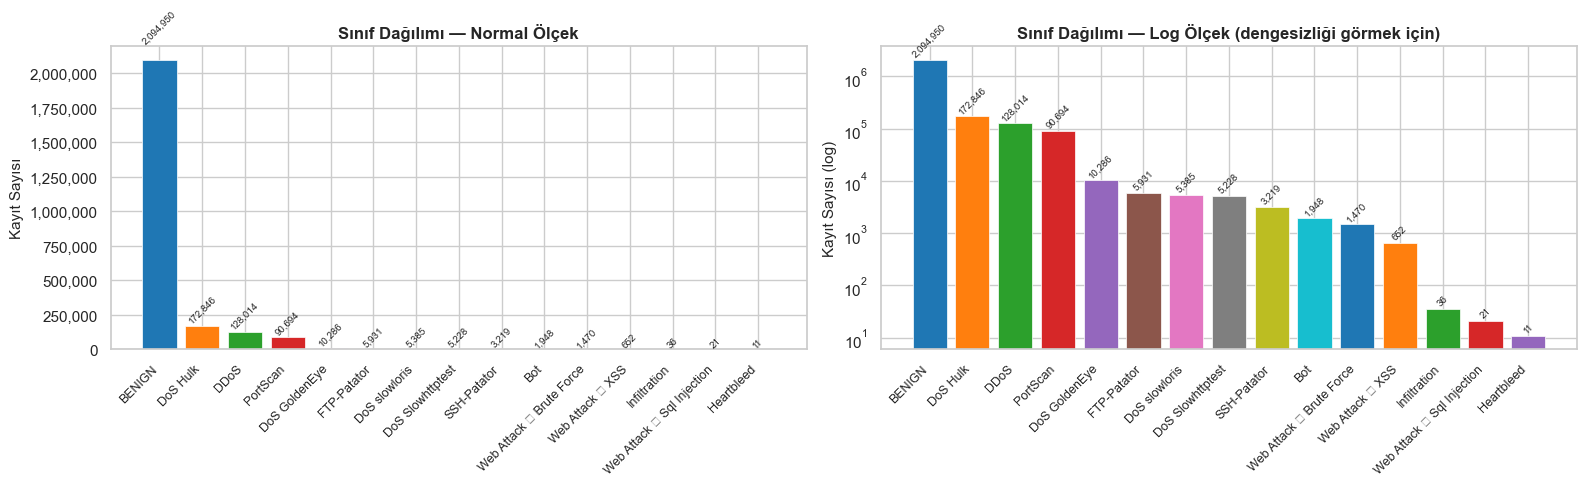

💾 figures/02_class_distribution.png kaydedildi


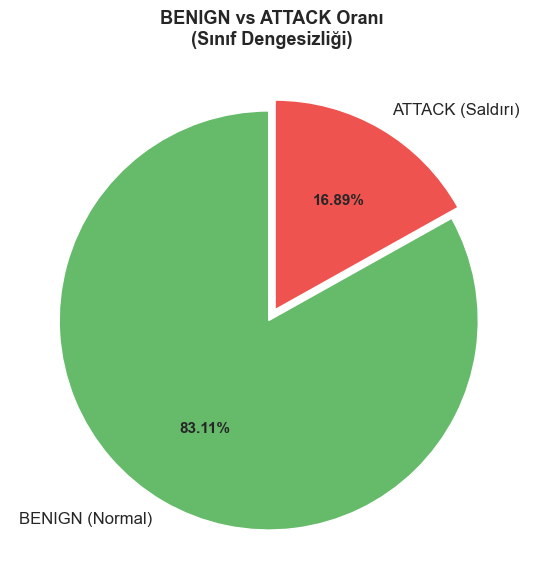

💾 figures/02b_benign_attack_pie.png kaydedildi

📊 Numerik Feature Özeti (ilk 10 feature):
       Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std
count        2520691.00   2.520691e+06         2520691.00              2520691.00                   2520691.00                 2.520691e+06             2520691.00              2520691.0              2520691.00             2520691.00
mean            8690.19   1.659232e+07              10.28                   11.57                       611.97                 1.814517e+04                 231.24                   19.2                   63.51                  77.33
std            19012.46   3.523334e+07             794.44                 1056.94                     10588.49                 2.398228e+06                 756.39                   60.8                  195.56  

In [5]:
# ============================================================
# ADIM 2: VERİ SETİ TANITIMI & EDA
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("=" * 60)
print("ADIM 2: VERİ SETİ TANITIMI & EDA")
print("=" * 60)

label_counts = y_labels.value_counts()
benign_n     = label_counts.get('BENIGN', 0)
attack_n     = len(y_labels) - benign_n

# --- 2.1 Sınıf dağılımı — normal ve log-scale ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = sns.color_palette("tab10", len(label_counts))

for ax, scale in zip(axes, ['linear', 'log']):
    bars = ax.bar(range(len(label_counts)), label_counts.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(label_counts)))
    ax.set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Kayıt Sayısı" + (" (log)" if scale == 'log' else ""), fontsize=11)
    ax.set_title(f"Sınıf Dağılımı — {'Log Ölçek (dengesizliği görmek için)' if scale=='log' else 'Normal Ölçek'}", fontweight='bold')
    if scale == 'log':
        ax.set_yscale('log')
    else:
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    # Her bar üstüne sayı yaz
    for i, (bar, val) in enumerate(zip(bars, label_counts.values)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
                f'{val:,}', ha='center', va='bottom', fontsize=7, rotation=45)

plt.tight_layout()
plt.savefig('figures/02_class_distribution.png', bbox_inches='tight')
plt.show()
print("💾 figures/02_class_distribution.png kaydedildi")

# --- 2.2 BENIGN vs ATTACK pasta grafiği ---
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    [benign_n, attack_n],
    labels=['BENIGN (Normal)', 'ATTACK (Saldırı)'],
    colors=['#66BB6A', '#EF5350'],
    autopct='%1.2f%%',
    explode=(0.03, 0.03),
    startangle=90,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.set_title("BENIGN vs ATTACK Oranı\n(Sınıf Dengesizliği)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02b_benign_attack_pie.png', bbox_inches='tight')
plt.show()
print("💾 figures/02b_benign_attack_pie.png kaydedildi")

# --- 2.3 Numerik özet istatistikler ---
print("\n📊 Numerik Feature Özeti (ilk 10 feature):")
print(X_features.iloc[:, :10].describe().round(2).to_string())

# --- 2.4 Veri tipi dağılımı ---
dtype_counts = X_features.dtypes.value_counts()
print(f"\n🔢 Veri tipleri:")
for dtype, count in dtype_counts.items():
    print(f"   {str(dtype):<10} → {count} kolon")

# --- 2.5 Her attack türü için istatistik ---
print("\n📋 Sınıf bazlı kayıt sayısı ve oranı:")
print("-" * 55)
for label, count in label_counts.items():
    bar = "█" * int(count / label_counts.max() * 30)
    pct = count / len(y_labels) * 100
    print(f"  {label:<38} {count:>8,}  %{pct:5.2f}  {bar}")

print("\n✅ ADIM 2 TAMAMLANDI")

ADIM 3: FEATURE ENGINEERING

📌 Feature selection için 100,000 örneklem alınıyor...
🌳 Random Forest eğitiliyor (feature selection için)...

🏆 En önemli 20 feature:
--------------------------------------------------
   1. Packet Length Std                   0.06748  █████████████████████████████████
   2. Packet Length Variance              0.05840  █████████████████████████████
   3. Avg Bwd Segment Size                0.05822  █████████████████████████████
   4. Max Packet Length                   0.04944  ████████████████████████
   5. Bwd Packet Length Max               0.04108  ████████████████████
   6. Total Length of Bwd Packets         0.03874  ███████████████████
   7. Subflow Fwd Bytes                   0.03856  ███████████████████
   8. Bwd Packet Length Std               0.03854  ███████████████████
   9. Average Packet Size                 0.03762  ██████████████████
  10. Subflow Bwd Bytes                   0.03404  █████████████████
  11. Subflow Fwd Packets              

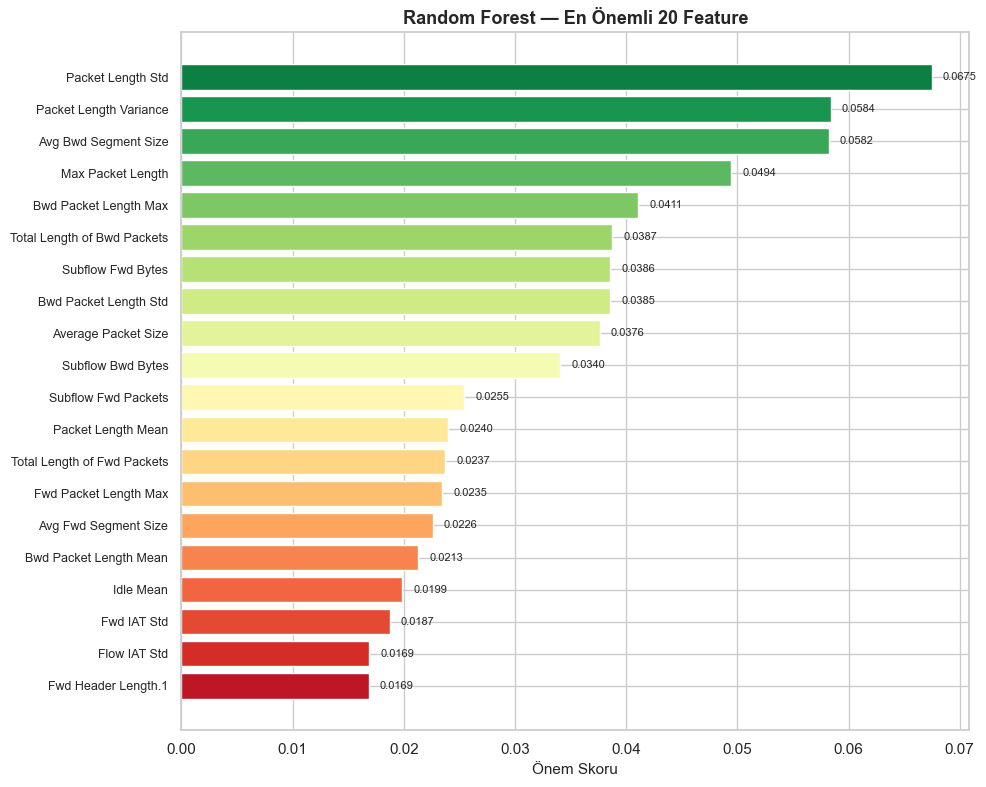

💾 figures/03a_feature_importance.png kaydedildi

✅ Seçilen 15 feature: ['Packet Length Std', 'Packet Length Variance', 'Avg Bwd Segment Size', 'Max Packet Length', 'Bwd Packet Length Max', 'Total Length of Bwd Packets', 'Subflow Fwd Bytes', 'Bwd Packet Length Std', 'Average Packet Size', 'Subflow Bwd Bytes', 'Subflow Fwd Packets', 'Packet Length Mean', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Avg Fwd Segment Size']
   X_selected_scaled boyutu: (2520691, 15)


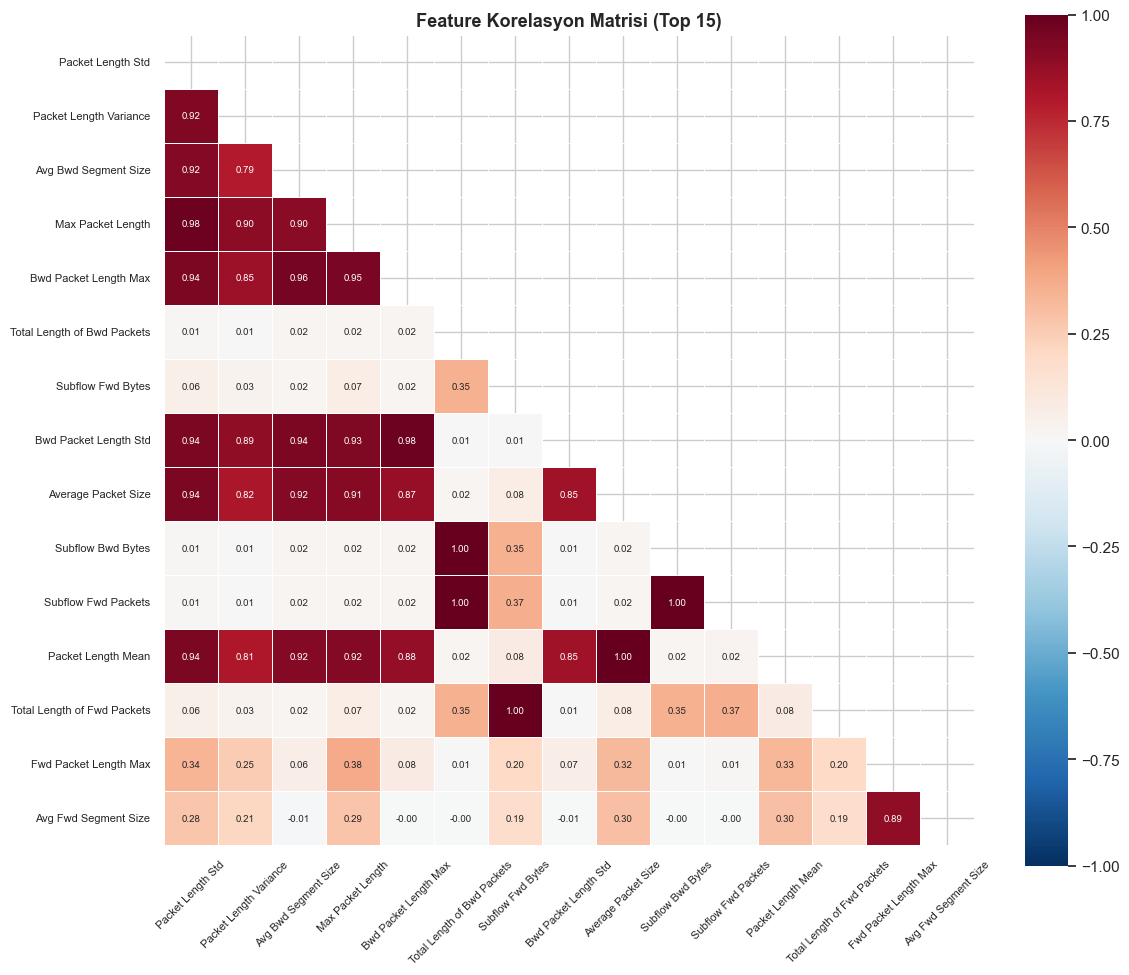


⚠️  Yüksek korelasyonlu feature çiftleri (|r| > 0.90):
   Packet Length Std                   ↔ Packet Length Variance              r=0.925
   Packet Length Std                   ↔ Avg Bwd Segment Size                r=0.918
   Packet Length Std                   ↔ Max Packet Length                   r=0.984
   Packet Length Std                   ↔ Bwd Packet Length Max               r=0.939
   Packet Length Std                   ↔ Bwd Packet Length Std               r=0.942
   Packet Length Std                   ↔ Average Packet Size                 r=0.943
   Packet Length Std                   ↔ Packet Length Mean                  r=0.943
   Avg Bwd Segment Size                ↔ Max Packet Length                   r=0.903
   Avg Bwd Segment Size                ↔ Bwd Packet Length Max               r=0.958
   Avg Bwd Segment Size                ↔ Bwd Packet Length Std               r=0.941
   Avg Bwd Segment Size                ↔ Average Packet Size                 r=0.915
   Avg Bw

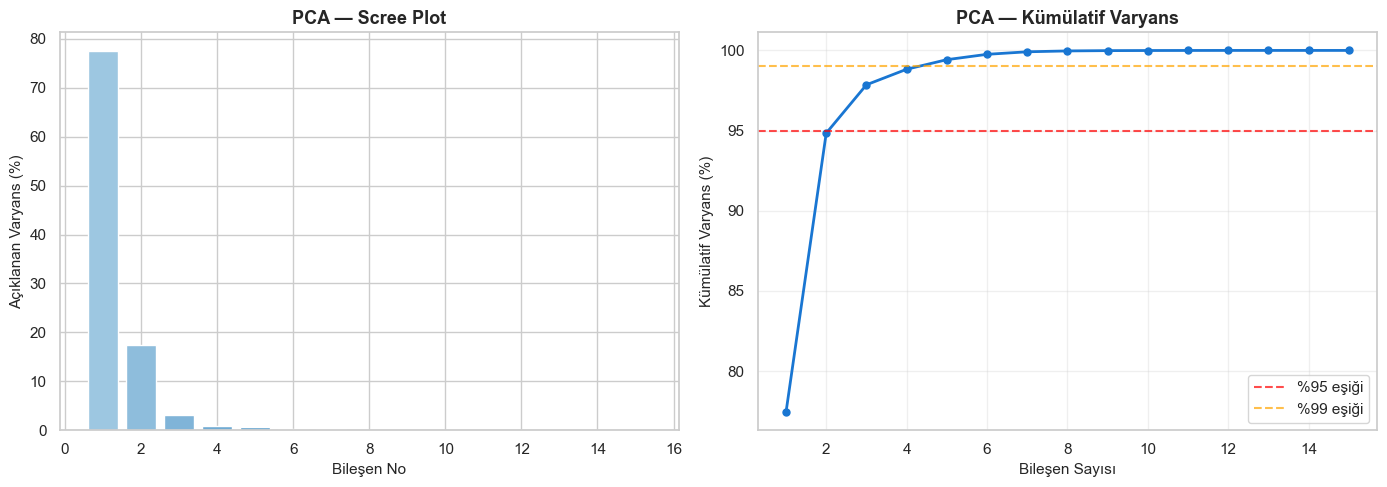

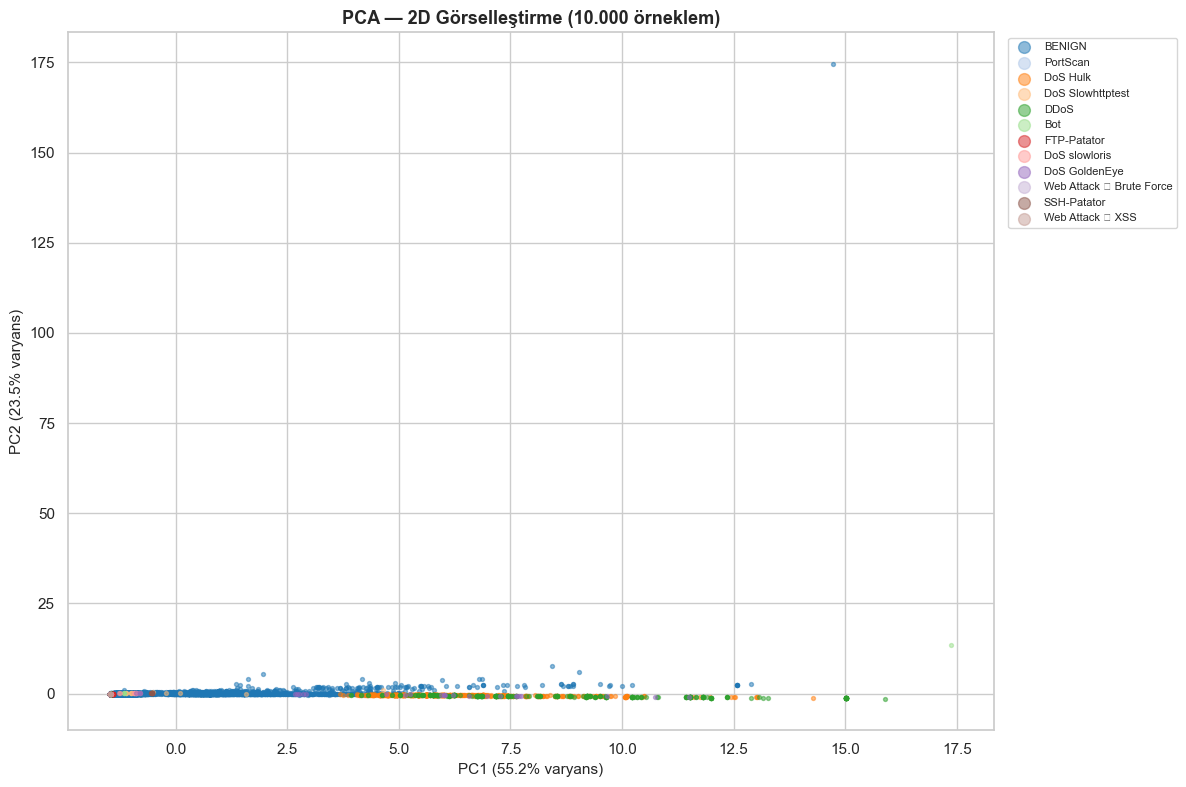


✅ ADIM 3 TAMAMLANDI — top_features, X_selected_scaled, scaler_final hazır


In [6]:
# ============================================================
# ADIM 3: FEATURE ENGINEERING
#         3a: Feature Selection  (Random Forest importance)
#         3b: Feature Extraction (PCA)
#         3c: Korelasyon analizi
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=" * 60)
print("ADIM 3: FEATURE ENGINEERING")
print("=" * 60)

# --- 3.1 Örneklem al (RAM yönetimi) ---
SAMPLE_SIZE = 100_000
print(f"\n📌 Feature selection için {SAMPLE_SIZE:,} örneklem alınıyor...")
df_sample = df.sample(SAMPLE_SIZE, random_state=42).copy()
y_sample  = df_sample['Label']
X_sample  = df_sample.drop(columns=['Label'])

# --- 3.2 Ölçekleme ---
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_sample),
    columns=X_sample.columns
)

# --- 3.3 Label encode (RF için) ---
le       = LabelEncoder()
y_enc    = le.fit_transform(y_sample)

# --- 3.4 Random Forest ile feature importance ---
print("🌳 Random Forest eğitiliyor (feature selection için)...")
rf_selector = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_scaled, y_enc)

importances = rf_selector.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : X_sample.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

TOP_N = 20
print(f"\n🏆 En önemli {TOP_N} feature:")
print("-" * 50)
for i, row in feat_imp_df.head(TOP_N).iterrows():
    bar = "█" * int(row['Importance'] * 500)
    print(f"  {i+1:>2}. {row['Feature']:<35} {row['Importance']:.5f}  {bar}")

# --- 3.5 Feature importance grafiği ---
fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_imp_df.head(TOP_N)
colors = sns.color_palette("RdYlGn_r", TOP_N)
bars = ax.barh(range(TOP_N), top20['Importance'].values, color=colors, edgecolor='white')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top20['Feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Önem Skoru", fontsize=11)
ax.set_title(f"Random Forest — En Önemli {TOP_N} Feature", fontsize=13, fontweight='bold')
for bar, val in zip(bars, top20['Importance'].values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('figures/03a_feature_importance.png', bbox_inches='tight')
plt.show()
print("💾 figures/03a_feature_importance.png kaydedildi")

# --- 3.6 Seçilen feature'ları kaydet ---
TOP_FEATURES_N = 15
top_features = feat_imp_df['Feature'].head(TOP_FEATURES_N).tolist()
print(f"\n✅ Seçilen {TOP_FEATURES_N} feature: {top_features}")

# Tüm veri seti üzerinde bu feature'larla X oluştur
X_selected_raw = X_features[top_features].copy()

# Tüm veri setini ölçekle
scaler_final = StandardScaler()
X_selected_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_selected_raw),
    columns=top_features
)
print(f"   X_selected_scaled boyutu: {X_selected_scaled.shape}")

# --- 3.7 Korelasyon matrisi (seçilen feature'lar) ---
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = X_selected_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # üçgeni maskele
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 7},
    vmin=-1, vmax=1
)
ax.set_title("Feature Korelasyon Matrisi (Top 15)", fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('figures/03b_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Yüksek korelasyonlu çiftleri rapor et
print("\n⚠️  Yüksek korelasyonlu feature çiftleri (|r| > 0.90):")
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.90:
            high_corr_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], r))
            print(f"   {corr_matrix.index[i]:<35} ↔ {corr_matrix.columns[j]:<35} r={r:.3f}")
if not high_corr_pairs:
    print("   Yüksek korelasyonlu çift bulunamadı.")

# --- 3.8 PCA — Feature Extraction ---
print("\n🔬 PCA uygulanıyor (tüm 15 feature → 2 ve 5 bileşen)...")
pca_2  = PCA(n_components=2,  random_state=42)
pca_5  = PCA(n_components=5,  random_state=42)
pca_full = PCA(random_state=42)

# Örneklem üzerinde uygula (görselleştirme için)
sample_idx = df.sample(10_000, random_state=42).index
X_pca_input = X_selected_scaled.loc[sample_idx] if hasattr(X_selected_scaled, 'loc') else X_selected_scaled.iloc[:10_000]

X_pca2 = pca_2.fit_transform(X_pca_input)
pca_full.fit(X_selected_scaled.iloc[:50_000])

# Explained variance
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
print(f"   2 bileşenle açıklanan varyans : %{pca_2.explained_variance_ratio_.sum()*100:.1f}")
print(f"   5 bileşenle açıklanan varyans : %{pca_5.fit(X_selected_scaled.iloc[:50_000]).explained_variance_ratio_.sum()*100:.1f}")
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"   %95 varyans için gereken bileşen sayısı: {n_95}")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained[:15])+1), explained[:15]*100,
            color=sns.color_palette("Blues_d", 15), edgecolor='white')
axes[0].set_xlabel("Bileşen No", fontsize=11)
axes[0].set_ylabel("Açıklanan Varyans (%)", fontsize=11)
axes[0].set_title("PCA — Scree Plot", fontsize=13, fontweight='bold')

axes[1].plot(range(1, len(cumulative[:15])+1), cumulative[:15]*100,
             'o-', color='#1976D2', linewidth=2, markersize=5)
axes[1].axhline(95, color='red', linestyle='--', alpha=0.7, label='%95 eşiği')
axes[1].axhline(99, color='orange', linestyle='--', alpha=0.7, label='%99 eşiği')
axes[1].set_xlabel("Bileşen Sayısı", fontsize=11)
axes[1].set_ylabel("Kümülatif Varyans (%)", fontsize=11)
axes[1].set_title("PCA — Kümülatif Varyans", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/03c_pca_scree.png', bbox_inches='tight')
plt.show()

# PCA 2D görselleştirme
y_sample_pca = y_labels.loc[sample_idx] if hasattr(y_labels, 'loc') else y_labels.iloc[:10_000]
unique_labels = y_sample_pca.unique()
color_map = dict(zip(unique_labels, sns.color_palette("tab20", len(unique_labels))))

fig, ax = plt.subplots(figsize=(12, 8))
for label in unique_labels:
    mask = y_sample_pca == label
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               label=label, alpha=0.5, s=8,
               color=color_map[label])
ax.set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% varyans)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% varyans)", fontsize=11)
ax.set_title("PCA — 2D Görselleştirme (10.000 örneklem)", fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, markerscale=3)
plt.tight_layout()
plt.savefig('figures/03d_pca_2d.png', bbox_inches='tight')
plt.show()

print("\n✅ ADIM 3 TAMAMLANDI — top_features, X_selected_scaled, scaler_final hazır")

ADIM 4: OUTLIER ANALİZİ & YORUMU

Analiz edilecek feature'lar: ['Max Packet Length', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Flow Bytes/s']

📊 IQR Outlier Özeti:
               Feature  Outlier Sayısı  Outlier %
     Max Packet Length          364265      14.45
         Flow Duration          468192      18.57
     Total Fwd Packets          253005      10.04
Total Backward Packets          239223       9.49
          Flow Bytes/s          474847      18.84


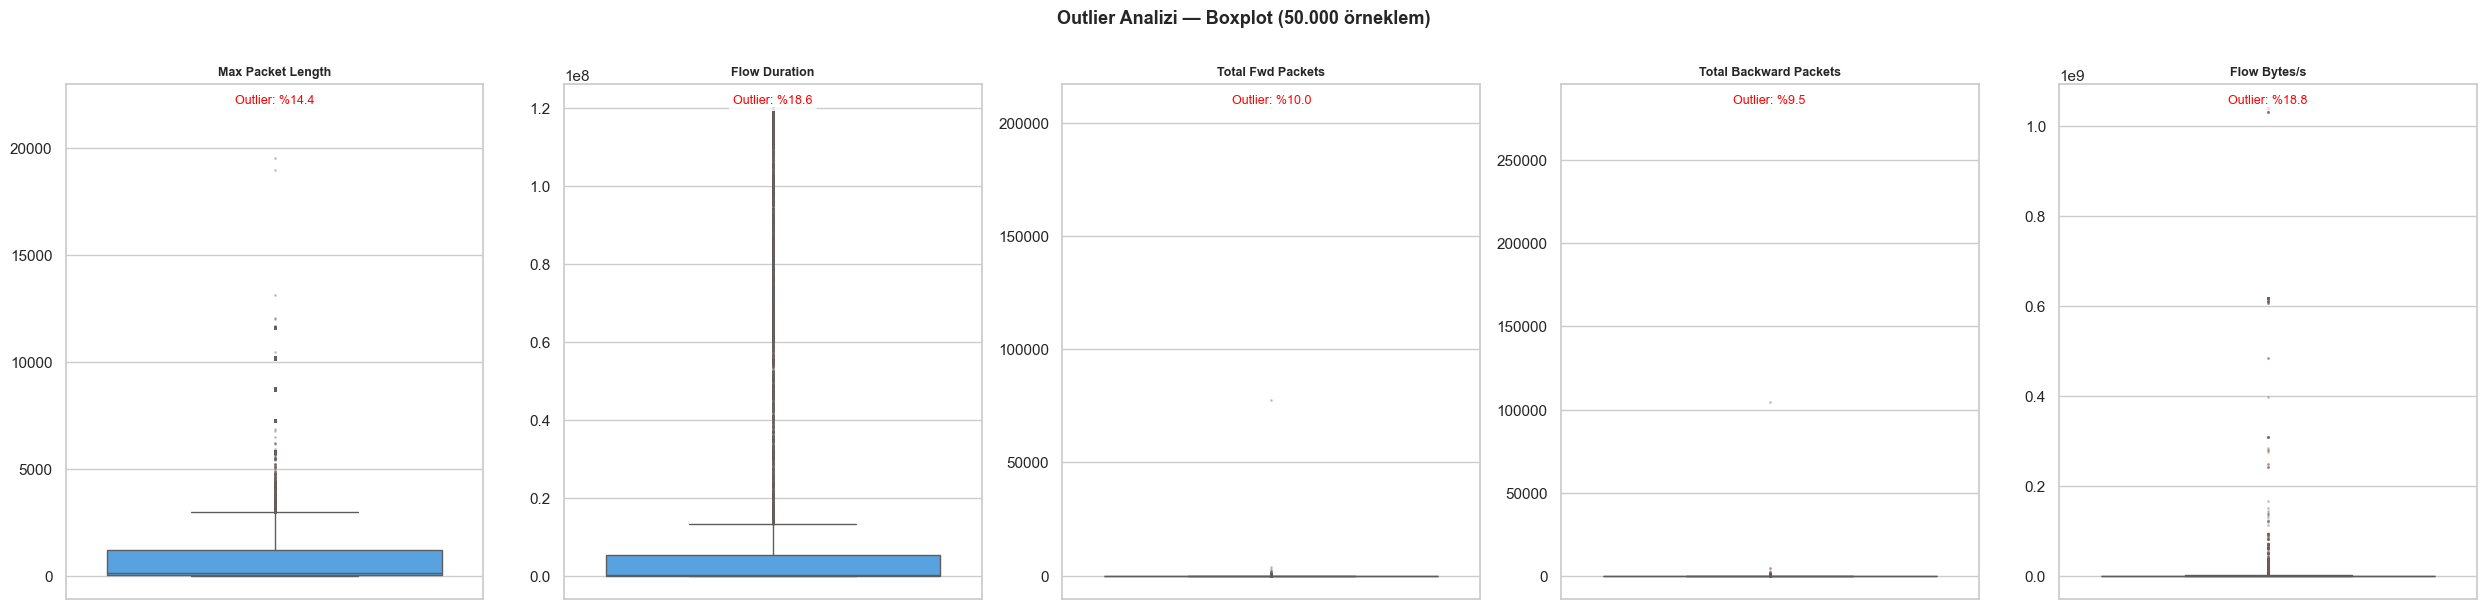


🔍 'Max Packet Length' outlier'larının saldırı türü dağılımı:
                            Normal Kayıt  Outlier Kayıt   Toplam  Outlier Oranı (%)
Label                                                                              
BENIGN                           1973874         121076  2094950                5.8
Bot                                 1903             45     1948                2.3
DDoS                               46668          81346   128014               63.5
DoS GoldenEye                       3455           6831    10286               66.4
DoS Hulk                           17994         154852   172846               89.6
DoS Slowhttptest                    5225              3     5228                0.1
DoS slowloris                       5382              3     5385                0.1
FTP-Patator                         5931              0     5931                0.0
Heartbleed                             0             11       11              100.0
Infiltration  

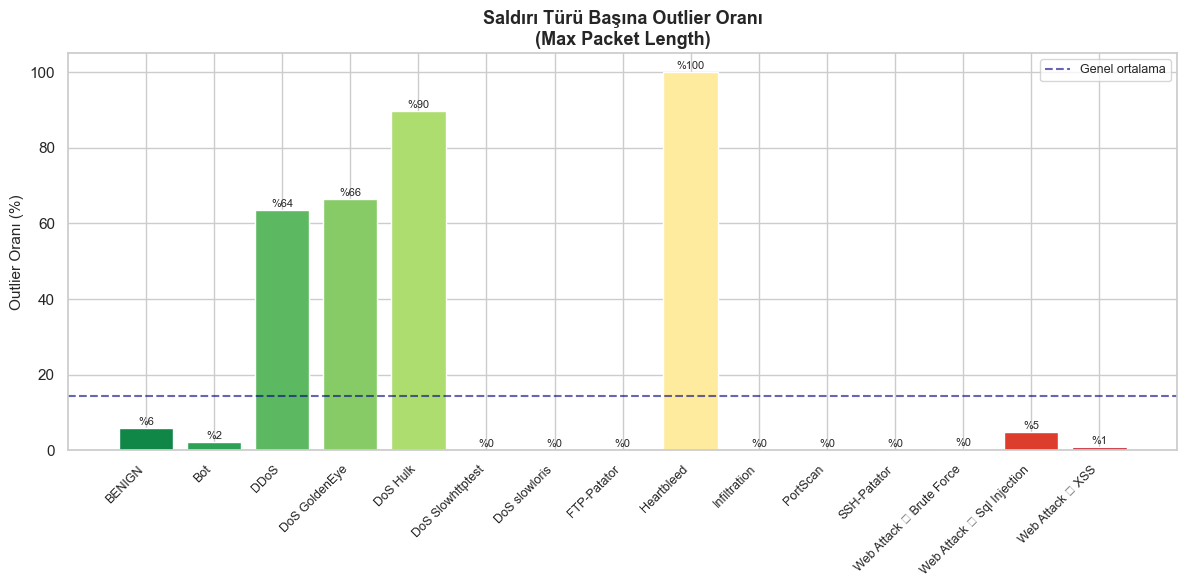

💾 figures/04b_outlier_per_attack.png kaydedildi

📝 YORUM:
   • Outlier kayıtların tamamı silinmemelidir — büyük paketler DoS ve PortScan
     gibi saldırıların doğal birer özelliğidir.
   • Outlier = anormal trafik sinyali olarak yorumlanabilir.
   • Isolation Forest bu outlier'ları zaten 'anomaly' olarak işaretleyecektir.
   • BENIGN'daki outlier'lar ise büyük dosya transferleri veya video akışları
     gibi meşru faaliyetlere karşılık gelir.

✅ ADIM 4 TAMAMLANDI


In [7]:
# ============================================================
# ADIM 4: OUTLIER ANALİZİ & YORUMU
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 60)
print("ADIM 4: OUTLIER ANALİZİ & YORUMU")
print("=" * 60)

# --- 4.1 IQR tabanlı outlier tespiti — birden fazla feature ---
analysis_features = [
    'Max Packet Length',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s'
]
# Var olan feature'ları seç
analysis_features = [f for f in analysis_features if f in X_features.columns]
print(f"\nAnaliz edilecek feature'lar: {analysis_features}")

outlier_summary = []
for feat in analysis_features:
    col_data = X_features[feat]
    Q1  = col_data.quantile(0.25)
    Q3  = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (col_data < lower) | (col_data > upper)
    n_outliers   = outlier_mask.sum()
    pct_outliers = n_outliers / len(col_data) * 100

    outlier_summary.append({
        'Feature'       : feat,
        'Q1'            : round(Q1, 2),
        'Q3'            : round(Q3, 2),
        'IQR'           : round(IQR, 2),
        'Alt Sınır'     : round(lower, 2),
        'Üst Sınır'     : round(upper, 2),
        'Outlier Sayısı': n_outliers,
        'Outlier %'     : round(pct_outliers, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\n📊 IQR Outlier Özeti:")
print(outlier_df[['Feature', 'Outlier Sayısı', 'Outlier %']].to_string(index=False))

# --- 4.2 Boxplot —tüm analiz feature'ları ---
fig, axes = plt.subplots(1, len(analysis_features), figsize=(5*len(analysis_features), 6))
if len(analysis_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, analysis_features):
    sample_data = X_features[[feat]].sample(min(50_000, len(X_features)), random_state=42)
    sns.boxplot(y=sample_data[feat], ax=ax, color='#42A5F5',
                flierprops=dict(marker='.', markerfacecolor='#EF5350', markersize=2, alpha=0.3))
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_ylabel("")
    # Üst outlier sayısını göster
    row = outlier_df[outlier_df['Feature'] == feat].iloc[0]
    ax.text(0.5, 0.98, f"Outlier: %{row['Outlier %']:.1f}",
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle("Outlier Analizi — Boxplot (50.000 örneklem)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/04a_outlier_boxplots.png', bbox_inches='tight')
plt.show()

# --- 4.3 ÖNEMLİ: Outlier'ların hangi saldırı türüne ait olduğu ---
print("\n🔍 'Max Packet Length' outlier'larının saldırı türü dağılımı:")
feat_main = 'Max Packet Length'
if feat_main in X_features.columns:
    col_data   = X_features[feat_main]
    Q1, Q3     = col_data.quantile(0.25), col_data.quantile(0.75)
    IQR        = Q3 - Q1
    upper      = Q3 + 1.5 * IQR
    lower      = Q1 - 1.5 * IQR
    outlier_mask = (col_data < lower) | (col_data > upper)

    df_outlier_labeled = pd.DataFrame({
        'Label'     : y_labels,
        'is_outlier': outlier_mask.values,
        feat_main   : col_data.values
    })

    # Saldırı türü × outlier çapraz tablosu
    cross_table = pd.crosstab(
        df_outlier_labeled['Label'],
        df_outlier_labeled['is_outlier'],
        margins=True,
        margins_name='TOPLAM'
    )
    cross_table.columns = ['Normal Kayıt', 'Outlier Kayıt', 'Toplam']
    cross_table['Outlier Oranı (%)'] = (
        cross_table['Outlier Kayıt'] / cross_table['Toplam'] * 100
    ).round(1)
    print(cross_table.to_string())

    # Görselleştir: Her saldırı türünde outlier oranı
    cross_no_total = cross_table.drop('TOPLAM')
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(range(len(cross_no_total)),
                  cross_no_total['Outlier Oranı (%)'],
                  color=sns.color_palette("RdYlGn_r", len(cross_no_total)),
                  edgecolor='white')
    ax.set_xticks(range(len(cross_no_total)))
    ax.set_xticklabels(cross_no_total.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Outlier Oranı (%)", fontsize=11)
    ax.set_title(f"Saldırı Türü Başına Outlier Oranı\n({feat_main})", fontsize=13, fontweight='bold')
    ax.axhline(outlier_df[outlier_df['Feature']==feat_main]['Outlier %'].values[0],
               color='navy', linestyle='--', alpha=0.6, label='Genel ortalama')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, cross_no_total['Outlier Oranı (%)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'%{val:.0f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig('figures/04b_outlier_per_attack.png', bbox_inches='tight')
    plt.show()
    print("💾 figures/04b_outlier_per_attack.png kaydedildi")

    print("""
📝 YORUM:
   • Outlier kayıtların tamamı silinmemelidir — büyük paketler DoS ve PortScan
     gibi saldırıların doğal birer özelliğidir.
   • Outlier = anormal trafik sinyali olarak yorumlanabilir.
   • Isolation Forest bu outlier'ları zaten 'anomaly' olarak işaretleyecektir.
   • BENIGN'daki outlier'lar ise büyük dosya transferleri veya video akışları
     gibi meşru faaliyetlere karşılık gelir.
""")

print("✅ ADIM 4 TAMAMLANDI")

ADIM 5: t-SNE GÖRSELLEŞTİRME

📌 t-SNE için 5000 örneklem alınıyor (her sınıftan dengeli)...
   Seçilen toplam örneklem : 4064
   Sınıf başına yaklaşık   : 270

⏳ t-SNE hesaplanıyor (bu 1-3 dakika sürebilir)...


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


   t-SNE tamamlandı (16.9 saniye)


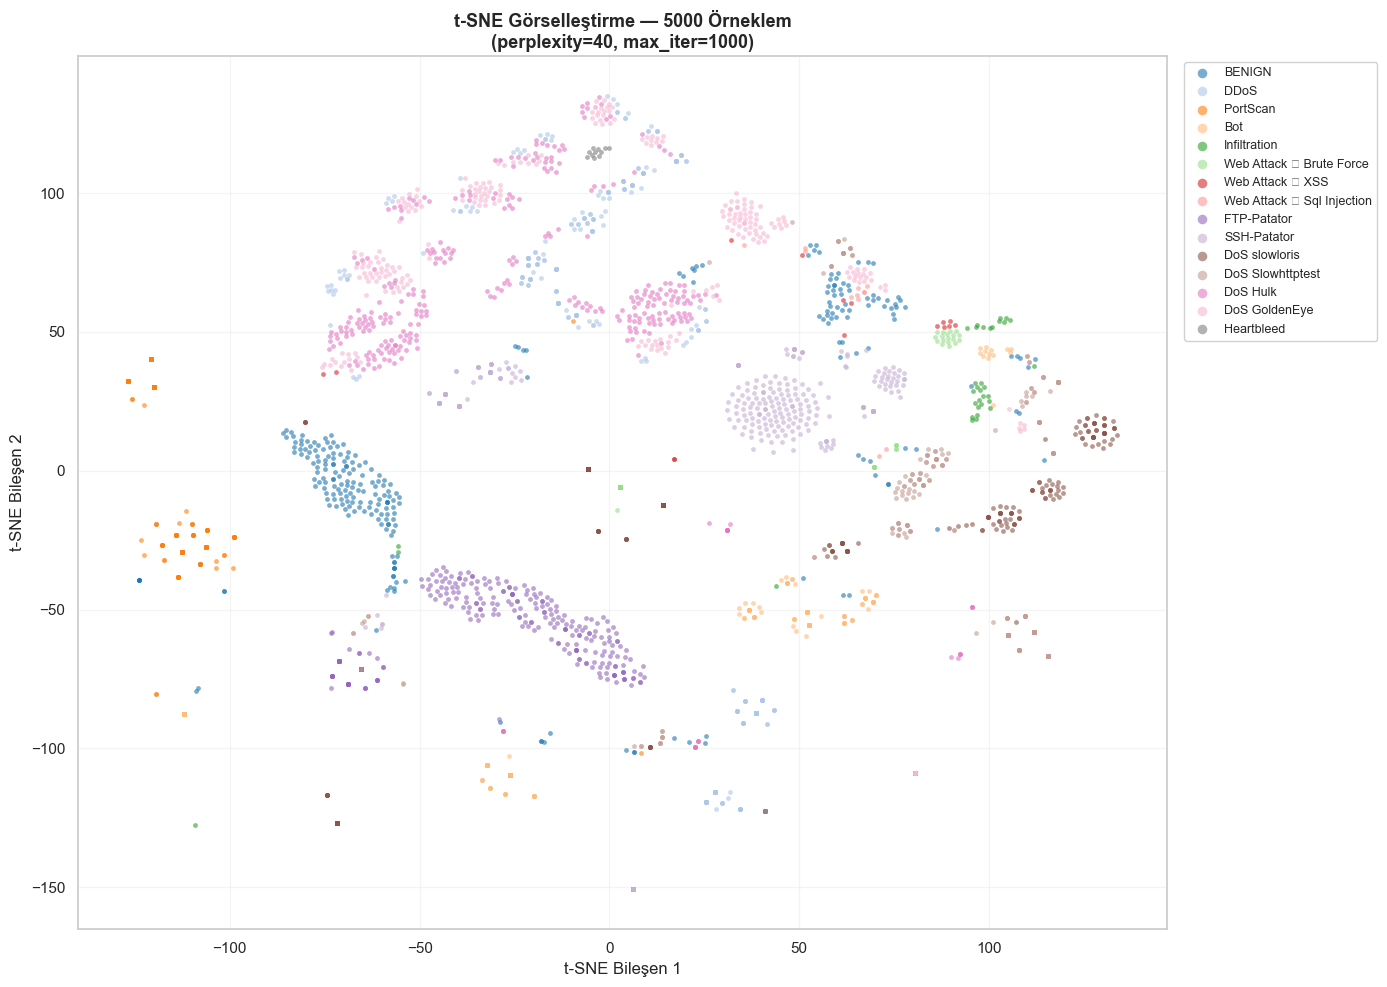

💾 figures/05a_tsne_all_classes.png kaydedildi


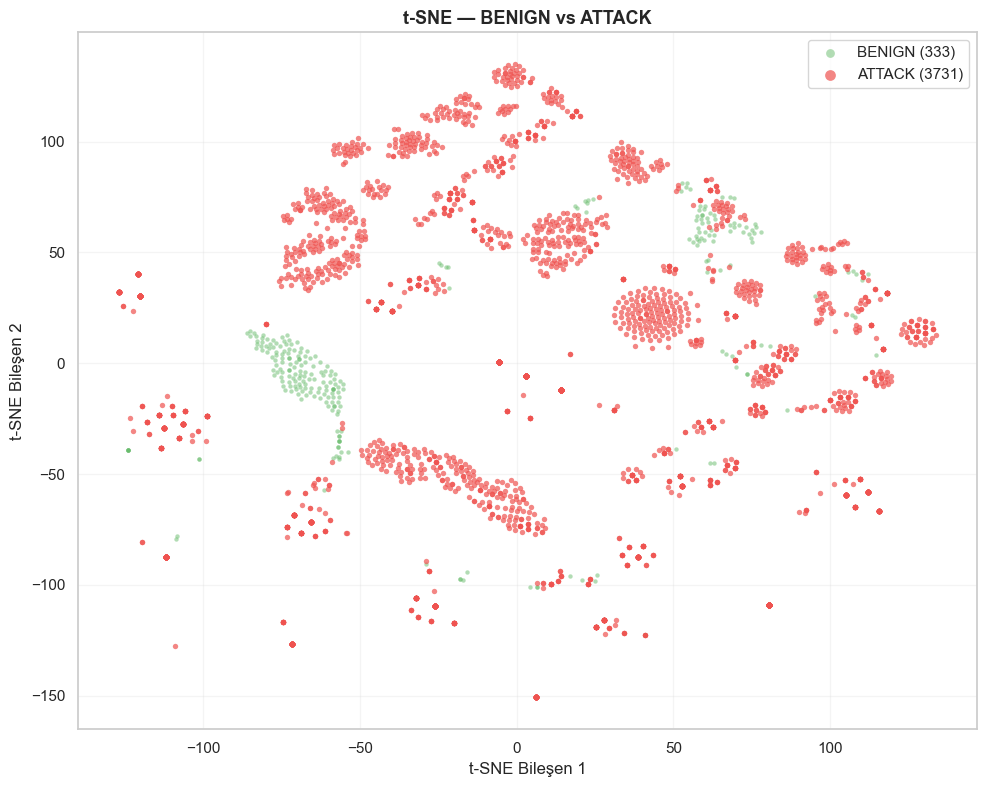

💾 figures/05b_tsne_binary.png kaydedildi

📝 t-SNE YORUMU:
   • Birbirinden ayrılmış kümeler → feature'lar saldırı türlerini iyi ayırt ediyor
   • BENIGN ile örtüşen attack kümeleri → bu saldırılar tespit edilmesi zor
   • Izole kümeler (örn. PortScan) → Isolation Forest bunları kolayca yakalar

✅ ADIM 5 TAMAMLANDI


In [8]:
# ============================================================
# ADIM 5: t-SNE GÖRSELLEŞTİRME
# ============================================================
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import time

print("=" * 60)
print("ADIM 5: t-SNE GÖRSELLEŞTİRME")
print("=" * 60)

# --- 5.1 Küçük örneklem (t-SNE O(n²) karmaşıklığında çalışır) ---
TSNE_SAMPLE = 5_000
print(f"\n📌 t-SNE için {TSNE_SAMPLE} örneklem alınıyor "
      f"(her sınıftan dengeli)...")

# Her sınıftan dengeli örneklem
def balanced_sample(X, y, n_total, random_state=42):
    labels = y.unique()
    n_per_class = max(1, n_total // len(labels))
    idx_list = []
    for lbl in labels:
        lbl_idx = y[y == lbl].index
        n_take  = min(n_per_class, len(lbl_idx))
        sampled = lbl_idx.to_series().sample(n_take, random_state=random_state)
        idx_list.extend(sampled.index.tolist())
    return idx_list

sample_idx = balanced_sample(X_selected_scaled, y_labels, TSNE_SAMPLE)
X_tsne_input = X_selected_scaled.loc[sample_idx].values
y_tsne_input = y_labels.loc[sample_idx]

print(f"   Seçilen toplam örneklem : {len(sample_idx)}")
print(f"   Sınıf başına yaklaşık   : {len(sample_idx)//y_labels.nunique()}")

# --- 5.2 t-SNE uygula ---
print("\n⏳ t-SNE hesaplanıyor (bu 1-3 dakika sürebilir)...")
t0 = time.time()
tsne = TSNE(
    n_components  = 2,
    perplexity    = 40,
    max_iter      = 1000,     # sklearn 1.5+ için max_iter (n_iter deprecated)
    learning_rate = 200,
    random_state  = 42,
    n_jobs        = -1
)
X_tsne = tsne.fit_transform(X_tsne_input)
elapsed = time.time() - t0
print(f"   t-SNE tamamlandı ({elapsed:.1f} saniye)")

# --- 5.3 Görselleştirme 1: Tüm sınıflar ---
unique_labels = y_tsne_input.unique()
palette = dict(zip(unique_labels, plt.cm.tab20.colors[:len(unique_labels)]))

fig, ax = plt.subplots(figsize=(14, 10))
for lbl in unique_labels:
    mask = y_tsne_input == lbl
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=lbl, alpha=0.6, s=12,
               color=palette[lbl], linewidths=0)
ax.set_xlabel("t-SNE Bileşen 1", fontsize=12)
ax.set_ylabel("t-SNE Bileşen 2", fontsize=12)
ax.set_title(f"t-SNE Görselleştirme — {TSNE_SAMPLE} Örneklem\n"
             f"(perplexity=40, max_iter=1000)", fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, markerscale=2,
          framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('figures/05a_tsne_all_classes.png', bbox_inches='tight')
plt.show()
print("💾 figures/05a_tsne_all_classes.png kaydedildi")

# --- 5.4 Görselleştirme 2: Binary (BENIGN vs ATTACK) ---
y_binary_tsne = (y_tsne_input != 'BENIGN').map({False: 'BENIGN', True: 'ATTACK'})

fig, ax = plt.subplots(figsize=(10, 8))
for lbl, color, size in [('BENIGN', '#66BB6A', 10), ('ATTACK', '#EF5350', 15)]:
    mask = y_binary_tsne == lbl
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=f"{lbl} ({mask.sum()})",
               alpha=0.5 if lbl=='BENIGN' else 0.7,
               s=size, color=color, linewidths=0)
ax.set_xlabel("t-SNE Bileşen 1", fontsize=12)
ax.set_ylabel("t-SNE Bileşen 2", fontsize=12)
ax.set_title("t-SNE — BENIGN vs ATTACK", fontsize=13, fontweight='bold')
ax.legend(fontsize=11, markerscale=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('figures/05b_tsne_binary.png', bbox_inches='tight')
plt.show()
print("💾 figures/05b_tsne_binary.png kaydedildi")

print("""
📝 t-SNE YORUMU:
   • Birbirinden ayrılmış kümeler → feature'lar saldırı türlerini iyi ayırt ediyor
   • BENIGN ile örtüşen attack kümeleri → bu saldırılar tespit edilmesi zor
   • Izole kümeler (örn. PortScan) → Isolation Forest bunları kolayca yakalar
""")
print("✅ ADIM 5 TAMAMLANDI")

ADIM 6: ISOLATION FOREST — ANOMALY DETECTION

📌 Isolation Forest için 200,000 örneklem alınıyor...
   Contamination (gerçek attack oranı): 0.1688 (16.9%)

⏳ Isolation Forest eğitiliyor...
   Eğitim tamamlandı (2.9 saniye)

📊 ISOLATION FOREST PERFORMANSI:
              precision    recall  f1-score   support

  BENIGN (0)     0.8958    0.8958    0.8958    166249
  ATTACK (1)     0.4865    0.4865    0.4865     33751

    accuracy                         0.8267    200000
   macro avg     0.6911    0.6911    0.6911    200000
weighted avg     0.8267    0.8267    0.8267    200000

Confusion Matrix Detayı:
   TN (BENIGN → BENIGN) :  148,918
   FP (BENIGN → ATTACK) :   17,331  ← Yanlış alarm
   FN (ATTACK → BENIGN) :   17,331  ← Gözden kaçan saldırı
   TP (ATTACK → ATTACK) :   16,420

   Tespit Oranı (Recall)  : 0.4865
   Yanlış Alarm Oranı     : 0.1042
   ROC-AUC                : 0.7428
   Avg Precision (PR-AUC) : 0.3550


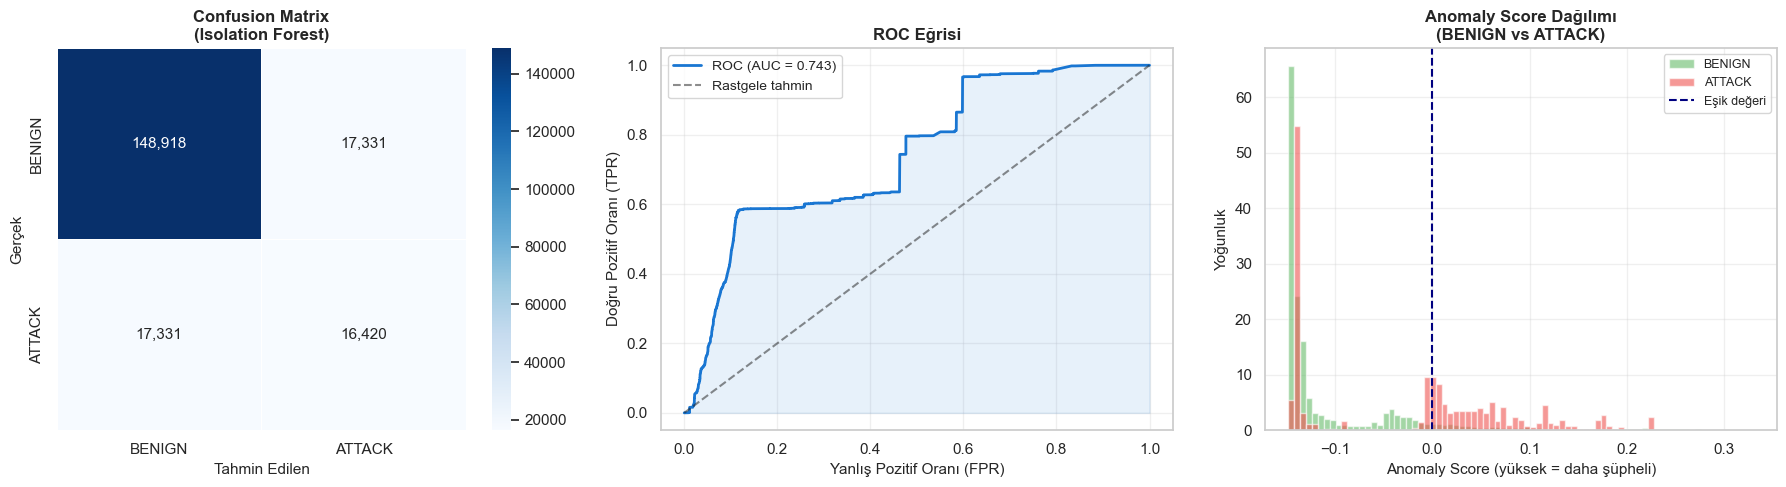

💾 figures/06a_isolation_forest_results.png kaydedildi

📋 Saldırı türü bazında tespit oranı:
                     Label  Toplam  Doğru Tahmin  Tespit Oranı %
               FTP-Patator     507             0             0.0
          Web Attack � XSS      52             0             0.0
                  PortScan    7172             7             0.1
             DoS slowloris     413             2             0.5
               SSH-Patator     255             5             2.0
                       Bot     152             5             3.3
  Web Attack � Brute Force     116             6             5.2
          DoS Slowhttptest     406            59            14.5
Web Attack � Sql Injection       4             1            25.0
              Infiltration       4             2            50.0
                      DDoS   10067          6409            63.7
             DoS GoldenEye     833           560            67.2
                  DoS Hulk   13769          9363            68.

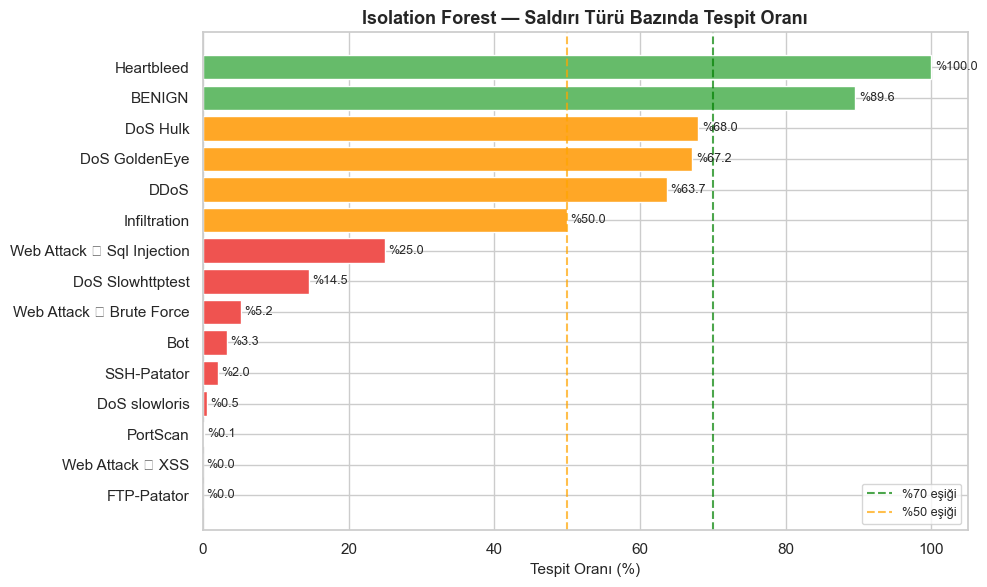

💾 figures/06b_detection_per_attack.png kaydedildi

✅ ADIM 6 TAMAMLANDI — iso_forest, if_results hazır


In [9]:
# ============================================================
# ADIM 6: ISOLATION FOREST — ANOMALY DETECTION
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time

print("=" * 60)
print("ADIM 6: ISOLATION FOREST — ANOMALY DETECTION")
print("=" * 60)

# --- 6.1 Model için örneklem ---
IF_SAMPLE = 200_000
print(f"\n📌 Isolation Forest için {IF_SAMPLE:,} örneklem alınıyor...")
sample_idx_if = df.sample(IF_SAMPLE, random_state=42).index
X_if  = X_selected_scaled.loc[sample_idx_if].values
y_if  = y_labels.loc[sample_idx_if]
y_bin = (y_if != 'BENIGN').astype(int)   # 0=BENIGN, 1=ATTACK

# Gerçek saldırı oranına göre contamination ayarla
contamination = float(y_bin.mean())
print(f"   Contamination (gerçek attack oranı): {contamination:.4f} ({contamination:.1%})")

# --- 6.2 Isolation Forest eğit ---
print("\n⏳ Isolation Forest eğitiliyor...")
t0 = time.time()
iso_forest = IsolationForest(
    n_estimators   = 200,       # daha fazla ağaç → daha kararlı
    contamination  = contamination,
    max_samples    = 'auto',
    random_state   = 42,
    n_jobs         = -1
)
iso_forest.fit(X_if)
elapsed = time.time() - t0
print(f"   Eğitim tamamlandı ({elapsed:.1f} saniye)")

# --- 6.3 Tahmin ---
# predict: -1 = anomaly (attack), +1 = normal (benign)
# decision_function: düşük skor → daha anomalous
y_pred_raw   = iso_forest.predict(X_if)
y_score      = -iso_forest.decision_function(X_if)   # negatif çevir: yüksek = anomalous

# -1 → 1 (attack), +1 → 0 (benign) dönüşümü
y_pred_binary = (y_pred_raw == -1).astype(int)

# --- 6.4 Performans metrikleri ---
print("\n📊 ISOLATION FOREST PERFORMANSI:")
print("=" * 55)
print(classification_report(
    y_bin, y_pred_binary,
    target_names=['BENIGN (0)', 'ATTACK (1)'],
    digits=4
))

cm = confusion_matrix(y_bin, y_pred_binary)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix Detayı:")
print(f"   TN (BENIGN → BENIGN) : {tn:>8,}")
print(f"   FP (BENIGN → ATTACK) : {fp:>8,}  ← Yanlış alarm")
print(f"   FN (ATTACK → BENIGN) : {fn:>8,}  ← Gözden kaçan saldırı")
print(f"   TP (ATTACK → ATTACK) : {tp:>8,}")
print(f"\n   Tespit Oranı (Recall)  : {tp/(tp+fn):.4f}")
print(f"   Yanlış Alarm Oranı     : {fp/(fp+tn):.4f}")

try:
    auc = roc_auc_score(y_bin, y_score)
    ap  = average_precision_score(y_bin, y_score)
    print(f"   ROC-AUC                : {auc:.4f}")
    print(f"   Avg Precision (PR-AUC) : {ap:.4f}")
except Exception as e:
    print(f"   AUC hesaplanamadı: {e}")
    auc, ap = None, None

# --- 6.5 Confusion Matrix görselleştirme ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Confusion matrix
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'],
            linewidths=0.5)
axes[0].set_xlabel("Tahmin Edilen", fontsize=11)
axes[0].set_ylabel("Gerçek", fontsize=11)
axes[0].set_title("Confusion Matrix\n(Isolation Forest)", fontsize=12, fontweight='bold')

# b) ROC eğrisi
if auc:
    fpr, tpr, _ = roc_curve(y_bin, y_score)
    axes[1].plot(fpr, tpr, color='#1976D2', lw=2, label=f'ROC (AUC = {auc:.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Rastgele tahmin')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1976D2')
    axes[1].set_xlabel("Yanlış Pozitif Oranı (FPR)", fontsize=11)
    axes[1].set_ylabel("Doğru Pozitif Oranı (TPR)", fontsize=11)
    axes[1].set_title("ROC Eğrisi", fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

# c) Anomaly score dağılımı
bins = np.linspace(y_score.min(), y_score.max(), 80)
axes[2].hist(y_score[y_bin==0], bins=bins, alpha=0.6, color='#66BB6A',
             label='BENIGN', density=True)
axes[2].hist(y_score[y_bin==1], bins=bins, alpha=0.6, color='#EF5350',
             label='ATTACK', density=True)
threshold_val = np.percentile(y_score, 100*(1-contamination))
axes[2].axvline(threshold_val, color='navy', linestyle='--', lw=1.5,
                label=f'Eşik değeri')
axes[2].set_xlabel("Anomaly Score (yüksek = daha şüpheli)", fontsize=11)
axes[2].set_ylabel("Yoğunluk", fontsize=11)
axes[2].set_title("Anomaly Score Dağılımı\n(BENIGN vs ATTACK)", fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/06a_isolation_forest_results.png', bbox_inches='tight')
plt.show()
print("💾 figures/06a_isolation_forest_results.png kaydedildi")

# --- 6.6 Her saldırı türü için tespit oranı ---
detection_per_type = []
for label in y_if.unique():
    mask    = y_if == label
    n_total = mask.sum()
    if label == 'BENIGN':
        n_correct = (y_pred_binary[mask] == 0).sum()   # BENIGN → doğru tahmin = 0
    else:
        n_correct = (y_pred_binary[mask] == 1).sum()   # ATTACK → doğru tahmin = 1
    detection_per_type.append({
        'Label'         : label,
        'Toplam'        : n_total,
        'Doğru Tahmin'  : n_correct,
        'Tespit Oranı %': round(n_correct / n_total * 100, 1)
    })

det_df = pd.DataFrame(detection_per_type).sort_values('Tespit Oranı %', ascending=True)
print("\n📋 Saldırı türü bazında tespit oranı:")
print(det_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors_det = ['#66BB6A' if r >= 70 else '#FFA726' if r >= 40 else '#EF5350'
              for r in det_df['Tespit Oranı %']]
bars = ax.barh(det_df['Label'], det_df['Tespit Oranı %'],
               color=colors_det, edgecolor='white')
ax.axvline(70, color='green', linestyle='--', alpha=0.7, label='%70 eşiği')
ax.axvline(50, color='orange', linestyle='--', alpha=0.7, label='%50 eşiği')
ax.set_xlabel("Tespit Oranı (%)", fontsize=11)
ax.set_title("Isolation Forest — Saldırı Türü Bazında Tespit Oranı",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, det_df['Tespit Oranı %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'%{val}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/06b_detection_per_attack.png', bbox_inches='tight')
plt.show()
print("💾 figures/06b_detection_per_attack.png kaydedildi")

# Sonuçları sonraki adımlar için sakla
if_results = {
    'y_true'        : y_bin,
    'y_pred'        : y_pred_binary,
    'y_score'       : y_score,
    'sample_idx'    : sample_idx_if,
    'model'         : iso_forest,
    'detection_df'  : det_df
}

print("\n✅ ADIM 6 TAMAMLANDI — iso_forest, if_results hazır")

ADIM 7: K-MEANS KÜMELEME

📌 K-Means için 50,000 örneklem alınıyor...

🔍 Optimal k değeri aranıyor (2-12 arası)...
   k= 2  inertia=467137  silhouette=0.8065
   k= 3  inertia=423147  silhouette=0.7385
   k= 4  inertia=352715  silhouette=0.7057
   k= 5  inertia=320694  silhouette=0.7227
   k= 6  inertia=317954  silhouette=0.4488
   k= 7  inertia=311443  silhouette=0.6477
   k= 8  inertia=310436  silhouette=0.4959
   k= 9  inertia=304580  silhouette=0.5303
   k=10  inertia=296250  silhouette=0.5481
   k=11  inertia=294763  silhouette=0.4780
   k=12  inertia=293038  silhouette=0.4498


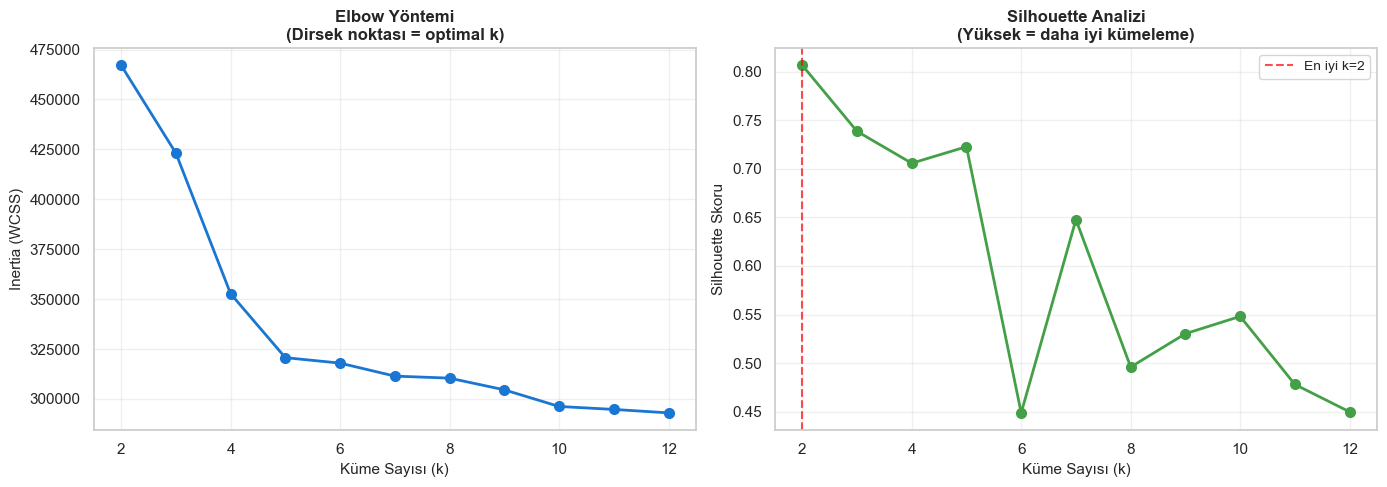


   Silhouette'e göre optimal k: 2
   Gerçek sınıf sayısı: 13
   → Her iki k değeri de denenecek: 2 ve 13

🎯 K-Means eğitiliyor (k=13)...
   Eğitim tamamlandı (0.4 saniye)
   Silhouette skoru: 0.4566
   Adjusted Rand Index (gerçek etiketle): 0.0476

📋 Küme kompozisyonu (baskın sınıf):
   Küme  0  →  BENIGN                               (%77)  [14,470 kayıt]
   Küme  1  →  DoS Hulk                             (%53)  [1,038 kayıt]
   Küme  2  →  DoS Hulk                             (%76)  [3,126 kayıt]
   Küme  3  →  BENIGN                               (%99)  [282 kayıt]
   Küme  4  →  BENIGN                               (%100)  [10,243 kayıt]
   Küme  5  →  BENIGN                               (%88)  [1,433 kayıt]
   Küme  6  →  BENIGN                               (%100)  [833 kayıt]
   Küme  7  →  BENIGN                               (%99)  [4,197 kayıt]
   Küme  8  →  BENIGN                               (%97)  [2,939 kayıt]
   Küme  9  →  BENIGN                               (%99)

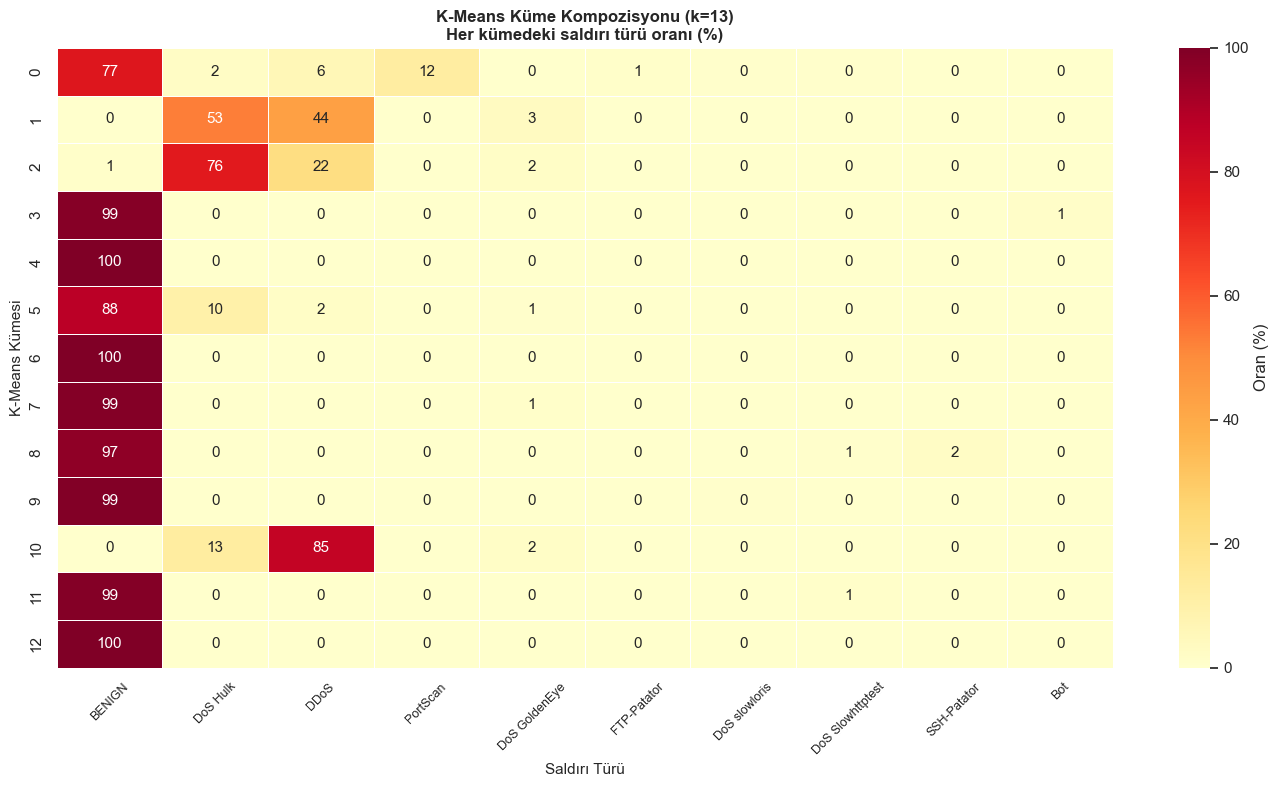

💾 figures/07b_kmeans_heatmap.png kaydedildi


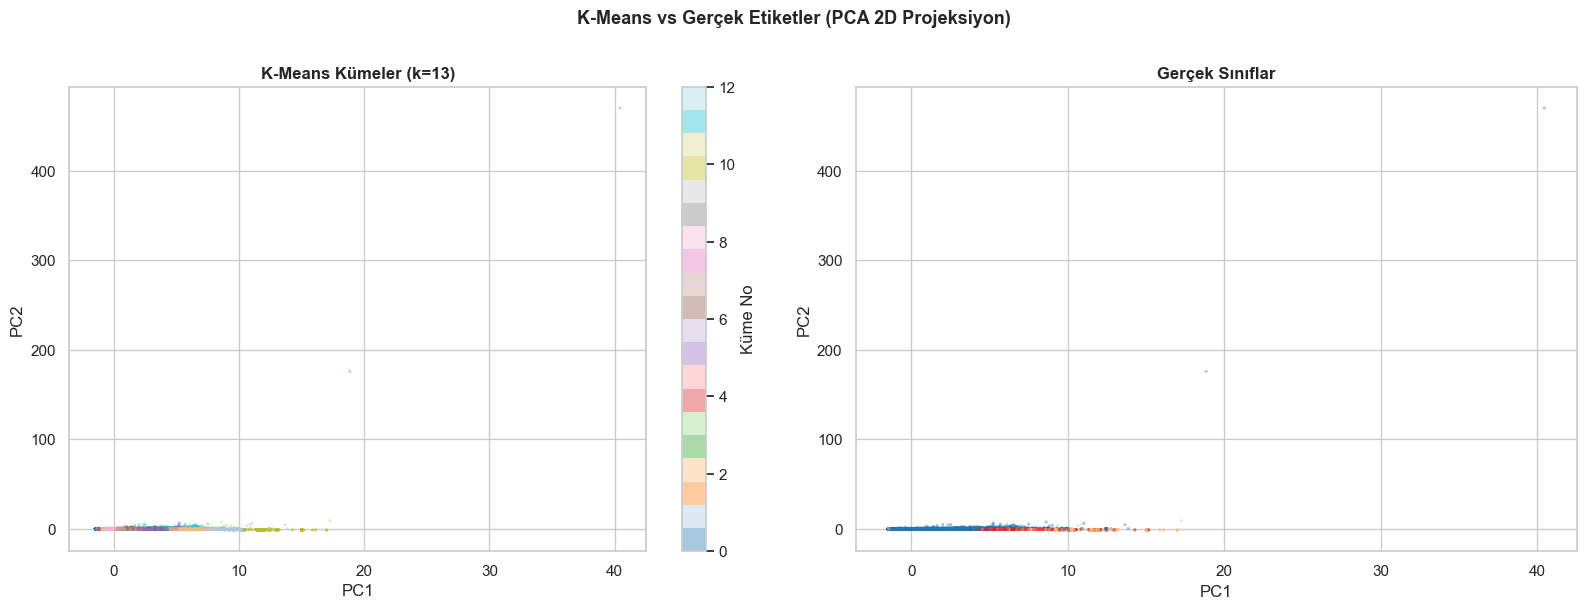


✅ ADIM 7 TAMAMLANDI — km_final, cluster_labels hazır


In [10]:
# ============================================================
# ADIM 7: K-MEANS KÜMELEME
# ============================================================
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time

print("=" * 60)
print("ADIM 7: K-MEANS KÜMELEME")
print("=" * 60)

# --- 7.1 Örneklem ---
KM_SAMPLE = 50_000
print(f"\n📌 K-Means için {KM_SAMPLE:,} örneklem alınıyor...")
sample_idx_km = df.sample(KM_SAMPLE, random_state=42).index
X_km  = X_selected_scaled.loc[sample_idx_km].values
y_km  = y_labels.loc[sample_idx_km]
y_km_bin = (y_km != 'BENIGN').astype(int)

# --- 7.2 Elbow yöntemi + Silhouette ile optimal k ---
print("\n🔍 Optimal k değeri aranıyor (2-12 arası)...")
k_range    = range(2, 13)
inertias   = []
silhouettes = []

for k in k_range:
    km_temp = MiniBatchKMeans(n_clusters=k, random_state=42,
                               batch_size=10_000, n_init=3)
    labels_temp = km_temp.fit_predict(X_km)
    inertias.append(km_temp.inertia_)
    sil = silhouette_score(X_km, labels_temp, sample_size=10_000, random_state=42)
    silhouettes.append(sil)
    print(f"   k={k:>2}  inertia={km_temp.inertia_:.0f}  silhouette={sil:.4f}")

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'o-', color='#1976D2', linewidth=2, markersize=7)
axes[0].set_xlabel("Küme Sayısı (k)", fontsize=11)
axes[0].set_ylabel("Inertia (WCSS)", fontsize=11)
axes[0].set_title("Elbow Yöntemi\n(Dirsek noktası = optimal k)", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

best_k_sil = list(k_range)[np.argmax(silhouettes)]
axes[1].plot(list(k_range), silhouettes, 'o-', color='#43A047', linewidth=2, markersize=7)
axes[1].axvline(best_k_sil, color='red', linestyle='--', alpha=0.7,
                label=f'En iyi k={best_k_sil}')
axes[1].set_xlabel("Küme Sayısı (k)", fontsize=11)
axes[1].set_ylabel("Silhouette Skoru", fontsize=11)
axes[1].set_title("Silhouette Analizi\n(Yüksek = daha iyi kümeleme)", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/07a_kmeans_optimal_k.png', bbox_inches='tight')
plt.show()
print(f"\n   Silhouette'e göre optimal k: {best_k_sil}")

# --- 7.3 Gerçek saldırı sınıfı sayısını da dene ---
n_actual_classes = y_km.nunique()
print(f"   Gerçek sınıf sayısı: {n_actual_classes}")
print(f"   → Her iki k değeri de denenecek: {best_k_sil} ve {n_actual_classes}")

# --- 7.4 Final K-Means modeli ---
K_FINAL = n_actual_classes   # gerçek sınıf sayısı akademik açıdan anlamlı
print(f"\n🎯 K-Means eğitiliyor (k={K_FINAL})...")
t0 = time.time()
km_final = MiniBatchKMeans(
    n_clusters  = K_FINAL,
    random_state= 42,
    batch_size  = 10_000,
    n_init      = 10,
    max_iter    = 300
)
cluster_labels = km_final.fit_predict(X_km)
elapsed = time.time() - t0
print(f"   Eğitim tamamlandı ({elapsed:.1f} saniye)")
sil_final = silhouette_score(X_km, cluster_labels, sample_size=10_000, random_state=42)
print(f"   Silhouette skoru: {sil_final:.4f}")

ari = adjusted_rand_score(y_km, cluster_labels)
print(f"   Adjusted Rand Index (gerçek etiketle): {ari:.4f}")

# --- 7.5 Her kümedeki saldırı türü dağılımı ---
cluster_df = pd.DataFrame({
    'Cluster': cluster_labels,
    'Label'  : y_km.values
})

# Her küme için baskın sınıfı bul
cluster_composition = cluster_df.groupby('Cluster')['Label'].value_counts(normalize=True).unstack(fill_value=0)
dominant_class = cluster_composition.idxmax(axis=1)
print("\n📋 Küme kompozisyonu (baskın sınıf):")
for c in range(K_FINAL):
    dominant = dominant_class[c]
    pct      = cluster_composition.loc[c, dominant] * 100
    size     = (cluster_labels == c).sum()
    print(f"   Küme {c:>2}  →  {dominant:<35}  (%{pct:.0f})  [{size:,} kayıt]")

# --- 7.6 Isı haritası: Küme × Saldırı türü ---
fig, ax = plt.subplots(figsize=(14, 8))
cluster_comp_pct = cluster_composition * 100
# Sadece en yaygın 10 sınıfı göster
top_labels_km = y_km.value_counts().head(10).index
cluster_comp_show = cluster_comp_pct[[l for l in top_labels_km if l in cluster_comp_pct.columns]]

sns.heatmap(cluster_comp_show, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Oran (%)'})
ax.set_xlabel("Saldırı Türü", fontsize=11)
ax.set_ylabel("K-Means Kümesi", fontsize=11)
ax.set_title(f"K-Means Küme Kompozisyonu (k={K_FINAL})\n"
             f"Her kümedeki saldırı türü oranı (%)", fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig('figures/07b_kmeans_heatmap.png', bbox_inches='tight')
plt.show()
print("💾 figures/07b_kmeans_heatmap.png kaydedildi")

# --- 7.7 PCA 2D'de küme görselleştirme ---
from sklearn.decomposition import PCA as PCA2
pca_km = PCA2(n_components=2, random_state=42)
X_km_2d = pca_km.fit_transform(X_km)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Sol: K-Means kümesi rengi
scatter1 = axes[0].scatter(X_km_2d[:, 0], X_km_2d[:, 1],
                            c=cluster_labels, cmap='tab20',
                            alpha=0.4, s=5, linewidths=0)
axes[0].set_title(f"K-Means Kümeler (k={K_FINAL})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(scatter1, ax=axes[0], label='Küme No')

# Sağ: Gerçek etiket rengi
y_km_encoded = pd.Categorical(y_km).codes
scatter2 = axes[1].scatter(X_km_2d[:, 0], X_km_2d[:, 1],
                            c=y_km_encoded, cmap='tab20',
                            alpha=0.4, s=5, linewidths=0)
axes[1].set_title("Gerçek Sınıflar", fontsize=12, fontweight='bold')
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.suptitle("K-Means vs Gerçek Etiketler (PCA 2D Projeksiyon)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/07c_kmeans_2d.png', bbox_inches='tight')
plt.show()

print("\n✅ ADIM 7 TAMAMLANDI — km_final, cluster_labels hazır")

ADIM 8: RANDOM FOREST — SUPERVISED KARŞILAŞTIRMA
   Toplam örneklem : 100,000
   Sınıf sayısı    : 15
   Sınıflar        : ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
   Stratify için güvenli sınıf sayısı: 14
   Eğitim seti : 79,999
   Test seti   : 20,000

🌳 Random Forest eğitiliyor...
   Eğitim tamamlandı (3.2 saniye)

📊 RANDOM FOREST PERFORMANSI:
   Accuracy: 0.8577

                          precision    recall  f1-score   support

                  BENIGN     0.9994    0.8322    0.9082     16647
                     Bot     0.0239    1.0000    0.0467        16
                    DDoS     0.9960    1.0000    0.9980      1001
           DoS GoldenEye     0.1098    0.9880    0.1976        83
                DoS Hulk     0.9364    0.9846    0.9599      1361
        DoS Slowhttptest     0.6

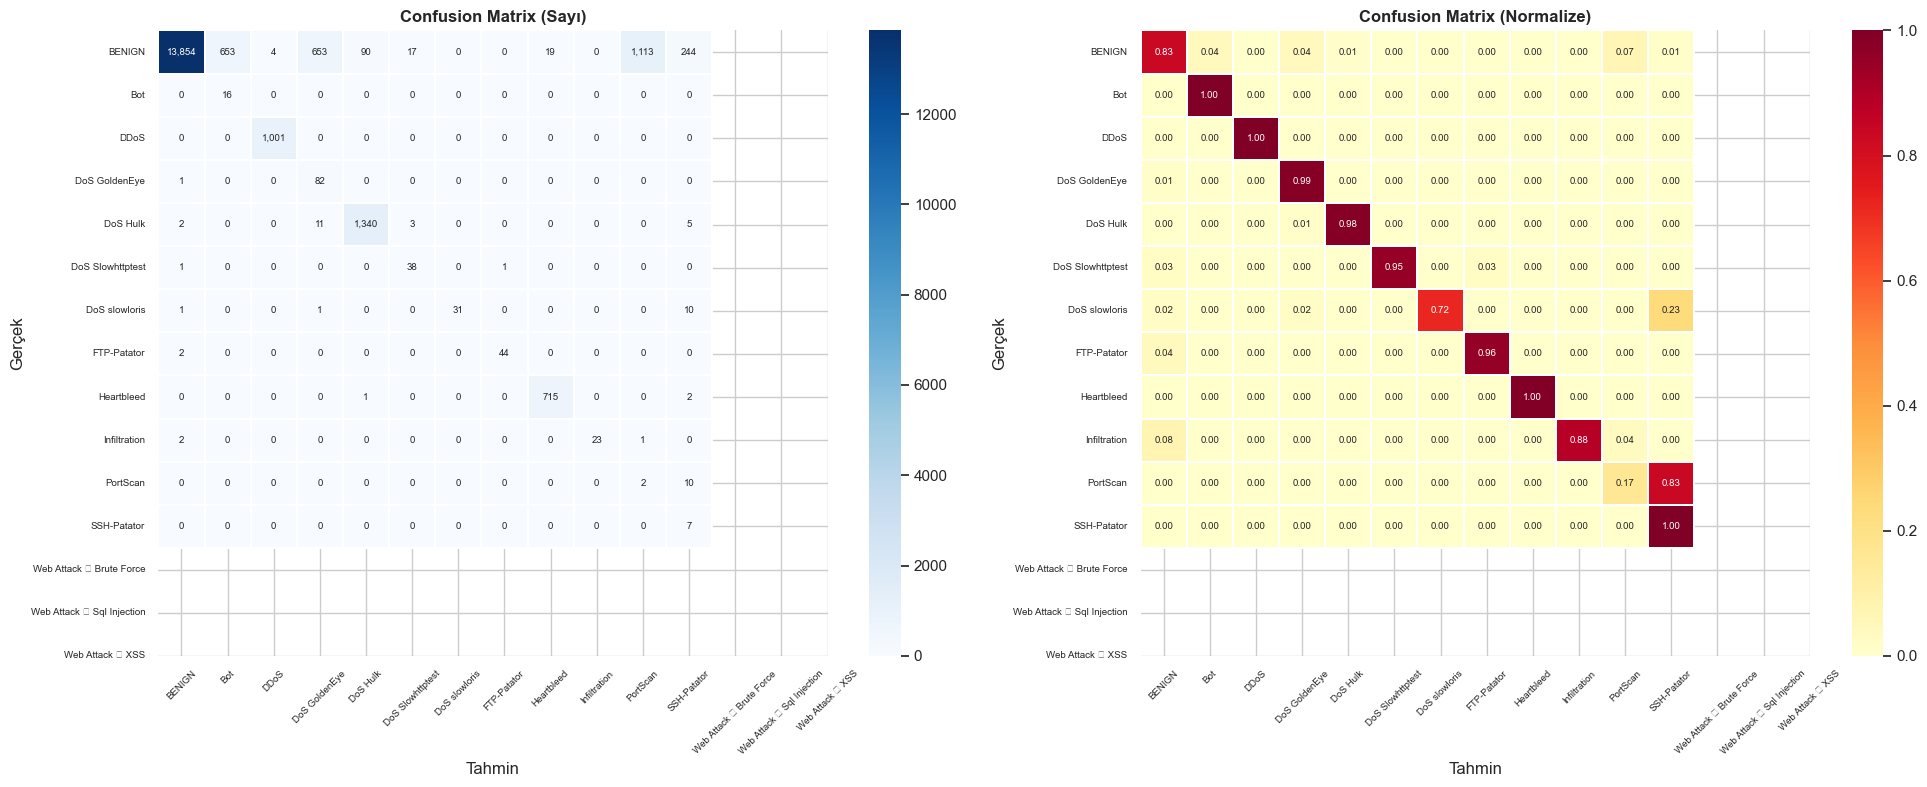

💾 figures/08a_rf_confusion_matrix.png kaydedildi

📊 MODEL KARŞILAŞTIRMA TABLOSU:
                                  Precision  Recall  F1 Score  Accuracy
Model                                                                  
Isolation Forest\n(Unsupervised)     0.4865  0.4865    0.4865    0.8267
Random Forest\n(Supervised)          0.5449  0.9973    0.7047    0.8599


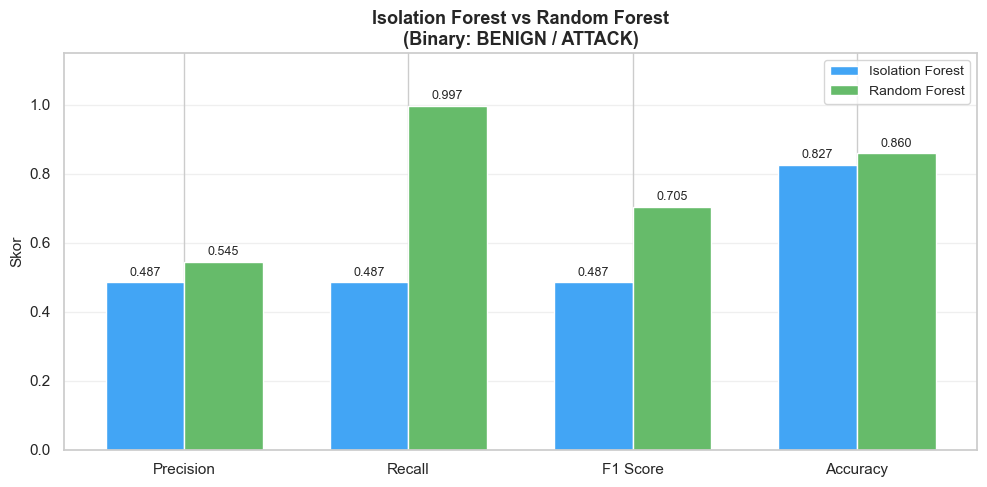

💾 figures/08b_model_comparison.png kaydedildi

✅ ADIM 8 TAMAMLANDI — rf_clf, rf_results hazır


In [13]:
# ============================================================
# ADIM 8: RANDOM FOREST SINIFLANDIRICI — SUPERVISED KARŞILAŞTIRMA
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time

print("=" * 60)
print("ADIM 8: RANDOM FOREST — SUPERVISED KARŞILAŞTIRMA")
print("=" * 60)

# --- 8.1 Örneklem ve hazırlık ---
RF_SAMPLE = 100_000

# Stratified split için test setinde de en az 1 üye gerekir.
# %20 test → bir sınıftan en az 5 üye olmalı (5 * 0.2 = 1)
MIN_CLASS_MEMBERS = 10   # güvenli eşik

counts       = y_labels.value_counts()
valid_labels = counts[counts >= MIN_CLASS_MEMBERS].index
mask_valid   = y_labels.isin(valid_labels)

dropped = set(y_labels.unique()) - set(valid_labels)
if dropped:
    print(f"⚠️  Çıkarılan sınıflar (< {MIN_CLASS_MEMBERS} üye): {dropped}")

df_pool  = df[mask_valid]
# Örneklem havuzdan küçükse tamamını al
n_sample = min(RF_SAMPLE, len(df_pool))
df_rf    = df_pool.sample(n_sample, random_state=42)

X_rf_raw = X_features.loc[df_rf.index][top_features].reset_index(drop=True)
y_rf     = y_labels.loc[df_rf.index].reset_index(drop=True)
y_rf_bin = (y_rf != 'BENIGN').astype(int)

le_rf    = LabelEncoder()
y_rf_enc = le_rf.fit_transform(y_rf)

X_rf_scaled = pd.DataFrame(
    scaler_final.transform(X_rf_raw),
    columns=top_features
)

print(f"   Toplam örneklem : {len(X_rf_scaled):,}")
print(f"   Sınıf sayısı    : {len(le_rf.classes_)}")
print(f"   Sınıflar        : {list(le_rf.classes_)}")

# --- 8.2 Eğitim / test bölmesi ---
# Örneklem sonrası tekrar kontrol et — sample şansla yine 1'e düşebilir
final_counts = pd.Series(y_rf_enc).value_counts()
safe_classes = final_counts[final_counts >= 2].index
mask_safe    = pd.Series(y_rf_enc).isin(safe_classes)

X_rf_safe  = X_rf_scaled[mask_safe.values].reset_index(drop=True)
y_rf_safe  = y_rf_enc[mask_safe.values]
ybin_safe  = y_rf_bin[mask_safe].reset_index(drop=True)

print(f"   Stratify için güvenli sınıf sayısı: {len(safe_classes)}")

X_train, X_test, y_train, y_test, y_bin_train, y_bin_test = train_test_split(
    X_rf_safe, y_rf_safe, ybin_safe,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_rf_safe
)
print(f"   Eğitim seti : {len(X_train):,}")
print(f"   Test seti   : {len(X_test):,}")

# --- 8.3 Random Forest eğit ---
print("\n🌳 Random Forest eğitiliyor...")
t0 = time.time()
rf_clf = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 20,
    min_samples_leaf = 5,
    random_state     = 42,
    n_jobs           = -1,
    class_weight     = 'balanced'
)
rf_clf.fit(X_train, y_train)
elapsed = time.time() - t0
print(f"   Eğitim tamamlandı ({elapsed:.1f} saniye)")

# --- 8.4 Tahmin ve metrikler ---
y_pred_rf     = rf_clf.predict(X_test)
y_pred_labels = le_rf.inverse_transform(y_pred_rf)
y_test_labels = le_rf.inverse_transform(y_test)

print(f"\n📊 RANDOM FOREST PERFORMANSI:")
print("=" * 55)
print(f"   Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n" + classification_report(
    y_test_labels, y_pred_labels,
    digits       = 4,
    zero_division= 0
))

# --- 8.5 Confusion matrix ---
class_names = le_rf.classes_
cm_rf      = confusion_matrix(y_test, y_pred_rf)
cm_rf_norm = cm_rf.astype(float) / cm_rf.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, annot_kws={'size': 7})
axes[0].set_title("Confusion Matrix (Sayı)", fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0,  labelsize=7)
axes[0].set_xlabel("Tahmin"); axes[0].set_ylabel("Gerçek")

sns.heatmap(cm_rf_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, annot_kws={'size': 7}, vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (Normalize)", fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0,  labelsize=7)
axes[1].set_xlabel("Tahmin"); axes[1].set_ylabel("Gerçek")

plt.tight_layout()
plt.savefig('figures/08a_rf_confusion_matrix.png', bbox_inches='tight')
plt.show()
print("💾 figures/08a_rf_confusion_matrix.png kaydedildi")

# --- 8.6 Isolation Forest vs Random Forest karşılaştırma ---
# Binary tahmin: RF için BENIGN dışı her şey = 1
benign_encoded = le_rf.transform(['BENIGN'])[0]
y_pred_rf_bin  = (y_pred_rf != benign_encoded).astype(int)

comparison = {
    'Model'    : ['Isolation Forest\n(Unsupervised)', 'Random Forest\n(Supervised)'],
    'Precision': [
        precision_score(if_results['y_true'], if_results['y_pred'], zero_division=0),
        precision_score(y_bin_test,           y_pred_rf_bin,         zero_division=0)
    ],
    'Recall'   : [
        recall_score(if_results['y_true'], if_results['y_pred']),
        recall_score(y_bin_test,           y_pred_rf_bin)
    ],
    'F1 Score' : [
        f1_score(if_results['y_true'], if_results['y_pred']),
        f1_score(y_bin_test,           y_pred_rf_bin)
    ],
    'Accuracy' : [
        accuracy_score(if_results['y_true'], if_results['y_pred']),
        accuracy_score(y_bin_test,           y_pred_rf_bin)
    ]
}
comp_df = pd.DataFrame(comparison).set_index('Model')
print("\n📊 MODEL KARŞILAŞTIRMA TABLOSU:")
print(comp_df.round(4).to_string())

# Grafik
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(comp_df.columns))
width = 0.35

bars1 = ax.bar(x - width/2, comp_df.iloc[0], width,
               label='Isolation Forest', color='#42A5F5', edgecolor='white')
bars2 = ax.bar(x + width/2, comp_df.iloc[1], width,
               label='Random Forest',    color='#66BB6A', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comp_df.columns, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Skor", fontsize=11)
ax.set_title("Isolation Forest vs Random Forest\n(Binary: BENIGN / ATTACK)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/08b_model_comparison.png', bbox_inches='tight')
plt.show()
print("💾 figures/08b_model_comparison.png kaydedildi")

# Sonraki adımlar için kaydet
rf_results = {
    'model'      : rf_clf,
    'le'         : le_rf,
    'X_test'     : X_test,
    'y_test'     : y_test,
    'y_test_bin' : y_bin_test.values,
    'y_pred_bin' : y_pred_rf_bin,
    'comp_df'    : comp_df
}

print("\n✅ ADIM 8 TAMAMLANDI — rf_clf, rf_results hazır")

✅ TensorFlow 2.21.0 bulundu
ADIM 9: AUTOENCODER — DEEP LEARNING ANOMALY DETECTION

📌 Veri hazırlanıyor...
   Eğitim seti (sadece BENIGN) : (40000, 15)
   Test seti (BENIGN + ATTACK) : (10000, 15)
   Feature sayısı              : 15


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6)              │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6)              │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 15)             │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 634 (2.48 KB)

 Trainable params: 570 (2.23 KB)

 Non-trainable params: 64 (256.00 B)


⏳ Autoencoder eğitiliyor...
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.8139 - val_loss: 0.3755 - learning_rate: 0.0010
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5179 - val_loss: 0.3430 - learning_rate: 0.0010
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3718 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2916 - val_loss: 0.3002 - learning_rate: 0.0010
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2355 - val_loss: 0.2771 - learning_rate: 0.0010
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1832 - val_loss: 0.2397 - learning_rate: 0.0010
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1416 - val_loss: 0.1809 - learning_rate: 0.0010
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1061 - val_loss: 0.1173 - learning_rate: 0.0010
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0813 - val_loss: 0.0836 - learning_rate: 0.001

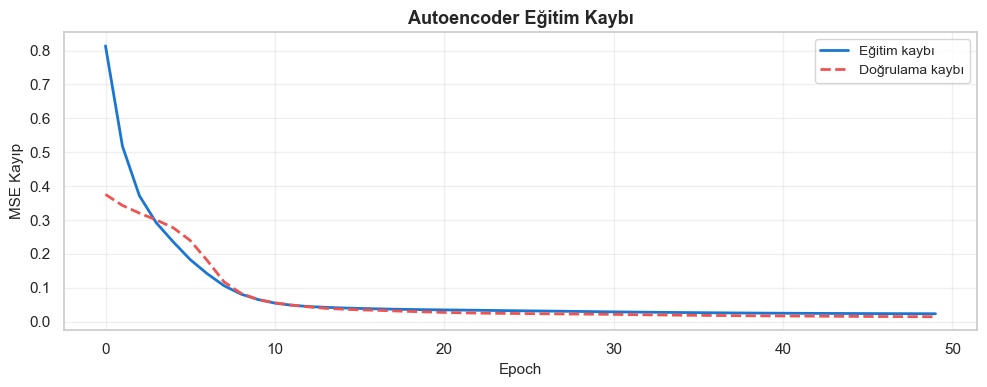

💾 figures/09a_autoencoder_loss.png kaydedildi

📊 Reconstruction Error:
   BENIGN  ort. hata : 0.020171
   ATTACK  ort. hata : 0.530258
   Eşik değeri (%95) : 0.054384

📊 AUTOENCODER PERFORMANSI (binary):
              precision    recall  f1-score   support

      BENIGN     0.6808    0.9500    0.7932      5000
      ATTACK     0.9173    0.5546    0.6913      5000

    accuracy                         0.7523     10000
   macro avg     0.7991    0.7523    0.7422     10000
weighted avg     0.7991    0.7523    0.7422     10000

   ROC-AUC : 0.7117
   PR-AUC  : 0.7907

📋 3 MODEL KARŞILAŞTIRMA:
                  Accuracy  Precision  Recall      F1
Model                                                
Isolation Forest    0.8267     0.4865  0.4865  0.4865
Autoencoder         0.7523     0.9173  0.5546  0.6913
Random Forest       0.8599     0.5449  0.9973  0.7047


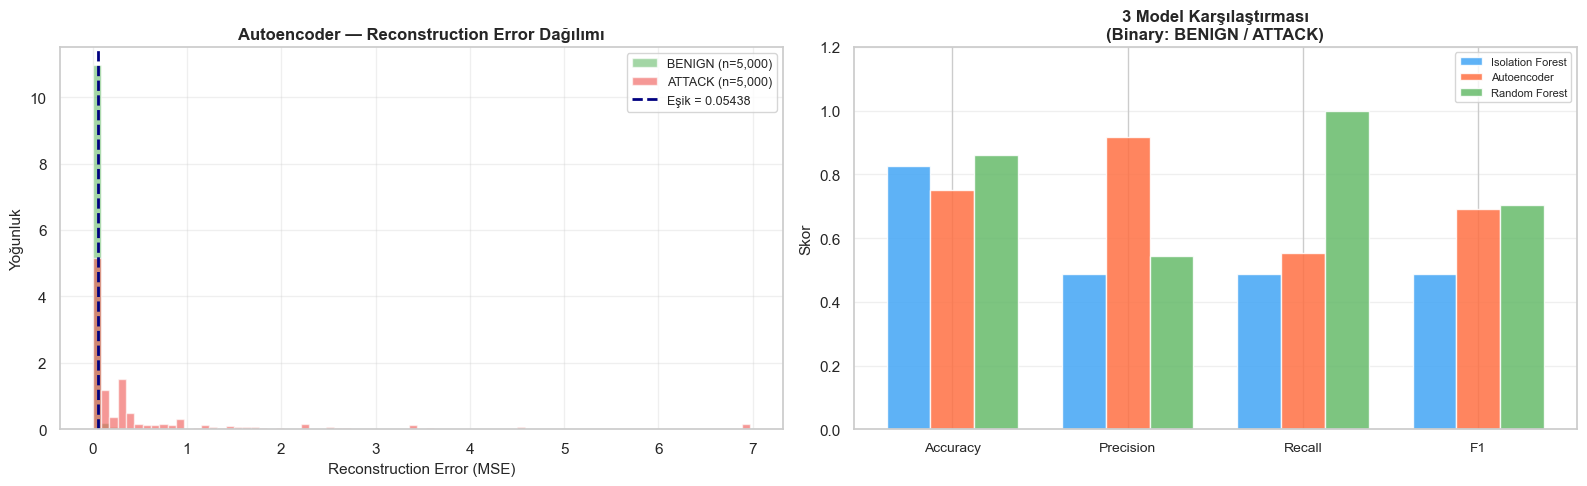

💾 figures/09b_autoencoder_comparison.png kaydedildi

✅ ADIM 9 TAMAMLANDI — autoencoder, ae_results, metrics_final_df hazır


In [15]:
# ============================================================
# ADIM 9: AUTOENCODER — DERİN ÖĞRENME TABANLI ANOMALY DETECTION
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    print(f"✅ TensorFlow {tf.__version__} bulundu")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow', '-q'])
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("=" * 60)
print("ADIM 9: AUTOENCODER — DEEP LEARNING ANOMALY DETECTION")
print("=" * 60)

# --- 9.1 Pozisyon bazlı veri hazırlama (index hatası önlenir) ---
print("\n📌 Veri hazırlanıyor...")

benign_positions = np.where(y_labels.values == 'BENIGN')[0]
attack_positions = np.where(y_labels.values != 'BENIGN')[0]

rng           = np.random.default_rng(42)
benign_chosen = rng.choice(benign_positions,
                           size    = min(45_000, len(benign_positions)),
                           replace = False)
attack_chosen = rng.choice(attack_positions,
                           size    = min(5_000, len(attack_positions)),
                           replace = False)

benign_train_pos = benign_chosen[:40_000]
benign_test_pos  = benign_chosen[40_000:]

X_ae_train       = X_selected_scaled.iloc[benign_train_pos].values.astype(np.float32)
X_ae_test_benign = X_selected_scaled.iloc[benign_test_pos].values.astype(np.float32)
X_ae_test_attack = X_selected_scaled.iloc[attack_chosen].values.astype(np.float32)

X_ae_test = np.vstack([X_ae_test_benign, X_ae_test_attack])
y_ae_test = np.array([0] * len(benign_test_pos) + [1] * len(attack_chosen))

input_dim = X_ae_train.shape[1]
print(f"   Eğitim seti (sadece BENIGN) : {X_ae_train.shape}")
print(f"   Test seti (BENIGN + ATTACK) : {X_ae_test.shape}")
print(f"   Feature sayısı              : {input_dim}")

# --- 9.2 Autoencoder mimarisi ---
encoding_dim = 3

inputs  = keras.Input(shape=(input_dim,), name="input")
x       = layers.Dense(10, activation='relu', name="enc_1")(inputs)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(6,  activation='relu', name="enc_2")(x)
x       = layers.BatchNormalization()(x)
encoded = layers.Dense(encoding_dim, activation='relu', name="bottleneck")(x)
x       = layers.Dense(6,  activation='relu', name="dec_1")(encoded)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(10, activation='relu', name="dec_2")(x)
x       = layers.BatchNormalization()(x)
decoded = layers.Dense(input_dim, activation='linear', name="output")(x)

autoencoder = keras.Model(inputs, decoded, name="Autoencoder")
encoder     = keras.Model(inputs, encoded, name="Encoder")

autoencoder.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'mse'
)
autoencoder.summary()

# --- 9.3 Eğitim ---
print("\n⏳ Autoencoder eğitiliyor...")

early_stop = keras.callbacks.EarlyStopping(
    monitor             = 'val_loss',
    patience            = 10,
    restore_best_weights= True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-5
)

history = autoencoder.fit(
    X_ae_train, X_ae_train,
    epochs           = 50,
    batch_size       = 1024,
    validation_split = 0.1,
    callbacks        = [early_stop, reduce_lr],
    verbose          = 1
)

# --- 9.4 Eğitim kaybı grafiği ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Eğitim kaybı',     color='#1976D2', linewidth=2)
ax.plot(history.history['val_loss'], label='Doğrulama kaybı',  color='#EF5350',
        linewidth=2, linestyle='--')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE Kayıp", fontsize=11)
ax.set_title("Autoencoder Eğitim Kaybı", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/09a_autoencoder_loss.png', bbox_inches='tight')
plt.show()
print("💾 figures/09a_autoencoder_loss.png kaydedildi")

# --- 9.5 Reconstruction error → anomaly score ---
X_ae_pred    = autoencoder.predict(X_ae_test, verbose=0)
recon_errors = np.mean(np.square(X_ae_test - X_ae_pred), axis=1)

benign_errors = recon_errors[:len(benign_test_pos)]
attack_errors = recon_errors[len(benign_test_pos):]
threshold_ae  = np.percentile(benign_errors, 95)

print(f"\n📊 Reconstruction Error:")
print(f"   BENIGN  ort. hata : {benign_errors.mean():.6f}")
print(f"   ATTACK  ort. hata : {attack_errors.mean():.6f}")
print(f"   Eşik değeri (%95) : {threshold_ae:.6f}")

y_pred_ae = (recon_errors > threshold_ae).astype(int)

# --- 9.6 Performans metrikleri ---
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, accuracy_score,
                              f1_score, precision_score, recall_score)

print("\n📊 AUTOENCODER PERFORMANSI (binary):")
print(classification_report(y_ae_test, y_pred_ae,
                             target_names=['BENIGN', 'ATTACK'], digits=4))
try:
    auc_ae = roc_auc_score(y_ae_test, recon_errors)
    ap_ae  = average_precision_score(y_ae_test, recon_errors)
    print(f"   ROC-AUC : {auc_ae:.4f}")
    print(f"   PR-AUC  : {ap_ae:.4f}")
except Exception as e:
    print(f"   AUC hesaplanamadı: {e}")

# --- 9.7 Reconstruction error dağılımı + 3 model karşılaştırması ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sol: hata dağılımı
bins = np.linspace(0, np.percentile(recon_errors, 99.5), 80)
axes[0].hist(benign_errors, bins=bins, alpha=0.6, color='#66BB6A',
             label=f'BENIGN (n={len(benign_errors):,})', density=True)
axes[0].hist(attack_errors, bins=bins, alpha=0.6, color='#EF5350',
             label=f'ATTACK (n={len(attack_errors):,})', density=True)
axes[0].axvline(threshold_ae, color='navy', linestyle='--', lw=2,
                label=f'Eşik = {threshold_ae:.5f}')
axes[0].set_xlabel("Reconstruction Error (MSE)", fontsize=11)
axes[0].set_ylabel("Yoğunluk", fontsize=11)
axes[0].set_title("Autoencoder — Reconstruction Error Dağılımı",
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sağ: 3 model karşılaştırması
benign_encoded_val = rf_results['le'].transform(['BENIGN'])[0]
y_pred_rf_b        = (rf_results['y_test'] != benign_encoded_val).astype(int)

models_data = {
    'Isolation Forest': (if_results['y_true'].values,       if_results['y_pred']),
    'Autoencoder'     : (y_ae_test,                          y_pred_ae),
    'Random Forest'   : (rf_results['y_test_bin'],           rf_results['y_pred_bin'])
}

metrics_rows = []
for name, (yt, yp) in models_data.items():
    metrics_rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(yt, yp),
        'Precision': precision_score(yt, yp, zero_division=0),
        'Recall'   : recall_score(yt, yp),
        'F1'       : f1_score(yt, yp)
    })

metrics_final_df = pd.DataFrame(metrics_rows).set_index('Model')
print("\n📋 3 MODEL KARŞILAŞTIRMA:")
print(metrics_final_df.round(4).to_string())

labels_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors3 = ['#42A5F5', '#FF7043', '#66BB6A']
x       = np.arange(len(labels_metrics))
width   = 0.25

for i, (name, row) in enumerate(metrics_final_df.iterrows()):
    axes[1].bar(x + i * width - width,
                [row['Accuracy'], row['Precision'], row['Recall'], row['F1']],
                width, label=name, color=colors3[i], edgecolor='white', alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_metrics, fontsize=10)
axes[1].set_ylim(0, 1.2)
axes[1].set_ylabel("Skor", fontsize=11)
axes[1].set_title("3 Model Karşılaştırması\n(Binary: BENIGN / ATTACK)",
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/09b_autoencoder_comparison.png', bbox_inches='tight')
plt.show()
print("💾 figures/09b_autoencoder_comparison.png kaydedildi")

# --- 9.8 Sonuçları kaydet ---
ae_results = {
    'model'        : autoencoder,
    'threshold'    : threshold_ae,
    'y_true'       : y_ae_test,
    'y_pred'       : y_pred_ae,
    'recon_errors' : recon_errors
}

metrics_final_df.to_csv('figures/model_comparison_table.csv')
print("\n✅ ADIM 9 TAMAMLANDI — autoencoder, ae_results, metrics_final_df hazır")

ADIM 10: GÜVENLİK UYARI SİSTEMİ & SONUÇLAR

🔍 Demo — Örnek akış tespiti:
-------------------------------------------------------

  🟢 Gerçek Etiket: BENIGN
     Risk Seviyesi  : LOW
     Aksiyon        : ALLOW — Normal trafik
     IF Skoru       : -0.13371
     AE Hatası      : 0.00117
     Zaman          : 2026-04-18 15:37:44

  🟡 Gerçek Etiket: DoS Hulk
     Risk Seviyesi  : MEDIUM
     Aksiyon        : ALERT — Analist incelemesine yönlendir
     IF Skoru       : -0.00238
     AE Hatası      : 0.07011
     Zaman          : 2026-04-18 15:37:44

  🟢 Gerçek Etiket: PortScan
     Risk Seviyesi  : LOW
     Aksiyon        : ALLOW — Normal trafik
     IF Skoru       : -0.14139
     AE Hatası      : 0.00129
     Zaman          : 2026-04-18 15:37:45

╔════════════════════════════════════════════════════════╗
║          GÜVENLİK UYARI SİSTEMİ AKIŞI                 ║
╚════════════════════════════════════════════════════════╝

  [Ağ Trafiği]
       ↓
  [Feature Extraction]   ← CICFlowMeter ile g

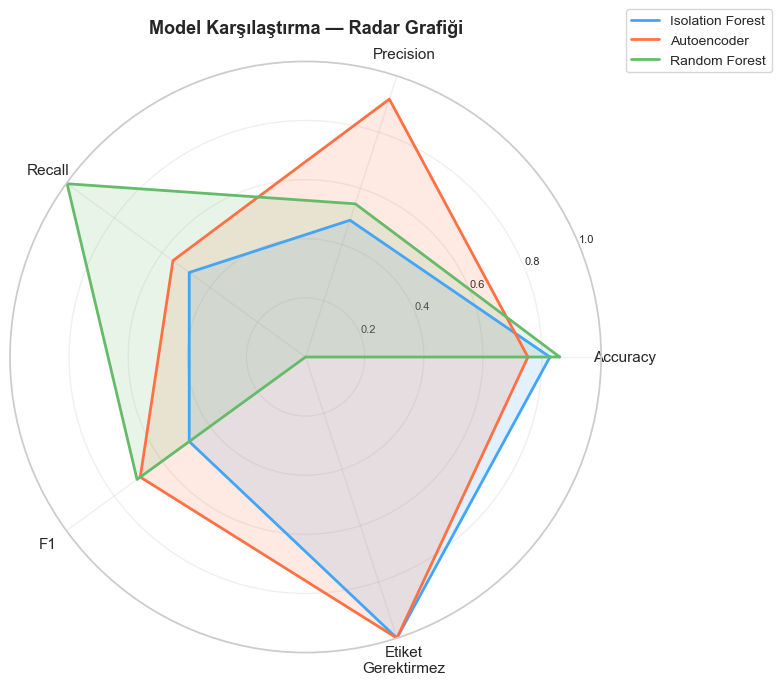

💾 figures/10_radar_comparison.png kaydedildi

NİHAİ SONUÇ RAPORU

VERİ SETİ  : CICIDS2017
Toplam kayıt: 2,520,691  |  Feature: 78  |  Sınıf: 15

UYGULANAN YÖNTEMLER:
  ✅  Veri temizleme   (Inf, NaN, duplicate)
  ✅  EDA              (dağılım, istatistik, boxplot)
  ✅  Feature selection (RF importance, Top-15)
  ✅  Feature extraction (PCA)
  ✅  Korelasyon analizi
  ✅  Outlier analizi   (IQR + saldırı türü yorumu)
  ✅  t-SNE görselleştirme
  ✅  Isolation Forest  (unsupervised anomaly)
  ✅  K-Means           (clustering)
  ✅  Random Forest     (supervised karşılaştırma)
  ✅  Autoencoder       (deep learning anomaly)
  ✅  Güvenlik uyarı sistemi

MODEL PERFORMANSI (BENIGN / ATTACK binary):

                  Accuracy  Precision  Recall      F1
Model                                                
Isolation Forest    0.8267     0.4865  0.4865  0.4865
Autoencoder         0.7523     0.9173  0.5546  0.6913
Random Forest       0.8599     0.5449  0.9973  0.7047

GÜÇLÜ YÖNLER:
  • Isolation Forest 

In [16]:
# ============================================================
# ADIM 10: GÜVENLİK UYARI SİSTEMİ & SONUÇLAR
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime
import json

print("=" * 60)
print("ADIM 10: GÜVENLİK UYARI SİSTEMİ & SONUÇLAR")
print("=" * 60)

# -------------------------------------------------------
# 10.1 Gerçek zamanlı anomaly detection fonksiyonu
# -------------------------------------------------------
def detect_anomaly(flow_data: dict,
                   model          = iso_forest,
                   scaler         = scaler_final,
                   features       = top_features,
                   threshold_score: float = 0.0,
                   ae_model       = ae_results['model'],
                   ae_threshold   : float = ae_results['threshold']
                   ) -> dict:
    """
    Tek bir ağ akışını analiz eder ve anomali tespiti yapar.

    Parametreler
    ------------
    flow_data : dict
        Feature → değer eşleşmesi (ham, ölçeklenmemiş)
    threshold_score : float
        Isolation Forest anomaly skoru eşiği (0 = varsayılan)

    Dönüş
    ------
    dict : tespit sonucu, risk seviyesi, açıklama
    """
    # Feature vektörüne dönüştür
    X_input = pd.DataFrame([flow_data])[features]

    # Eksik feature'ları 0 ile doldur
    for col in features:
        if col not in X_input.columns:
            X_input[col] = 0.0

    X_scaled_input = scaler.transform(X_input)

    # --- Isolation Forest skoru ---
    if_score = -iso_forest.decision_function(X_scaled_input)[0]
    if_pred  = iso_forest.predict(X_scaled_input)[0]   # -1 veya +1

    # --- Autoencoder reconstruction error ---
    X_ae_input = X_scaled_input.astype(np.float32)
    recon       = ae_model.predict(X_ae_input, verbose=0)
    ae_error    = float(np.mean(np.square(X_ae_input - recon)))

    # --- Karar mantığı ---
    is_anomaly_if = (if_pred == -1)
    is_anomaly_ae = (ae_error > ae_threshold)

    # İki model de anomaly diyorsa → HIGH RISK
    # Biri diyorsa → MEDIUM RISK
    # Hiçbiri demiyorsa → LOW RISK
    if is_anomaly_if and is_anomaly_ae:
        risk_level  = "HIGH"
        alert_color = "🔴"
        action      = "BLOCK — Trafik engellendi, olay kaydedildi"
    elif is_anomaly_if or is_anomaly_ae:
        risk_level  = "MEDIUM"
        alert_color = "🟡"
        action      = "ALERT — Analist incelemesine yönlendir"
    else:
        risk_level  = "LOW"
        alert_color = "🟢"
        action      = "ALLOW — Normal trafik"

    return {
        'timestamp'         : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'risk_level'        : risk_level,
        'alert_emoji'       : alert_color,
        'action'            : action,
        'isolation_forest'  : {
            'anomaly_score' : round(float(if_score), 6),
            'is_anomaly'    : bool(is_anomaly_if)
        },
        'autoencoder'       : {
            'reconstruction_error': round(ae_error, 6),
            'threshold'           : round(ae_threshold, 6),
            'is_anomaly'          : bool(is_anomaly_ae)
        }
    }


# -------------------------------------------------------
# 10.2 Demo: Sistem üzerinde birkaç akışı test et
# -------------------------------------------------------
print("\n🔍 Demo — Örnek akış tespiti:")
print("-" * 55)

# Gerçek veri setinden 3 örnek al: 1 BENIGN, 1 DoS, 1 PortScan
for target_label in ['BENIGN', 'DoS Hulk', 'PortScan']:
    idx_pool = y_labels[y_labels == target_label]
    if len(idx_pool) == 0:
        continue
    sample_idx_demo = idx_pool.sample(1, random_state=42).index[0]
    flow_dict = X_features.loc[sample_idx_demo][top_features].to_dict()

    result = detect_anomaly(flow_dict)
    true_label = y_labels.loc[sample_idx_demo]

    print(f"\n  {result['alert_emoji']} Gerçek Etiket: {true_label}")
    print(f"     Risk Seviyesi  : {result['risk_level']}")
    print(f"     Aksiyon        : {result['action']}")
    print(f"     IF Skoru       : {result['isolation_forest']['anomaly_score']:.5f}")
    print(f"     AE Hatası      : {result['autoencoder']['reconstruction_error']:.5f}")
    print(f"     Zaman          : {result['timestamp']}")

# -------------------------------------------------------
# 10.3 Alert akış diyagramı (metin tabanlı)
# -------------------------------------------------------
print("""
╔════════════════════════════════════════════════════════╗
║          GÜVENLİK UYARI SİSTEMİ AKIŞI                 ║
╚════════════════════════════════════════════════════════╝

  [Ağ Trafiği]
       ↓
  [Feature Extraction]   ← CICFlowMeter ile gerçek ortamda
       ↓
  ┌────────────────────┐
  │  Isolation Forest  │  → Anomaly Score
  └────────────────────┘
       +
  ┌────────────────────┐
  │   Autoencoder      │  → Reconstruction Error
  └────────────────────┘
       ↓
  ╔══════════════════════════════════╗
  ║  Her ikisi de ANOMALY?           ║
  ║  → 🔴 HIGH RISK → BLOCK + LOG   ║
  ║  Biri ANOMALY?                   ║
  ║  → 🟡 MEDIUM RISK → ANALİST    ║
  ║  Hiçbiri ANOMALY değil?          ║
  ║  → 🟢 LOW RISK → ALLOW          ║
  ╚══════════════════════════════════╝
""")

# -------------------------------------------------------
# 10.4 Final model karşılaştırma grafiği — radar chart
# -------------------------------------------------------
from matplotlib.patches import FancyArrowPatch

categories = ['Accuracy', 'Precision', 'Recall', 'F1', 'Etiket\nGerektirmez']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# Normalize edilmiş skorlar (etiket gerektirmez: IF=1, AE=1, RF=0)
scores = {
    'Isolation Forest': [
        metrics_final_df.loc['Isolation Forest', 'Accuracy'],
        metrics_final_df.loc['Isolation Forest', 'Precision'],
        metrics_final_df.loc['Isolation Forest', 'Recall'],
        metrics_final_df.loc['Isolation Forest', 'F1'],
        1.0
    ],
    'Autoencoder': [
        metrics_final_df.loc['Autoencoder', 'Accuracy'],
        metrics_final_df.loc['Autoencoder', 'Precision'],
        metrics_final_df.loc['Autoencoder', 'Recall'],
        metrics_final_df.loc['Autoencoder', 'F1'],
        1.0
    ],
    'Random Forest': [
        metrics_final_df.loc['Random Forest', 'Accuracy'],
        metrics_final_df.loc['Random Forest', 'Precision'],
        metrics_final_df.loc['Random Forest', 'Recall'],
        metrics_final_df.loc['Random Forest', 'F1'],
        0.0
    ]
}
colors_radar = ['#42A5F5', '#FF7043', '#66BB6A']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for (name, vals), color in zip(scores.items(), colors_radar):
    vals_plot = vals + [vals[0]]
    ax.plot(angles, vals_plot, color=color, linewidth=2, label=name)
    ax.fill(angles, vals_plot, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title("Model Karşılaştırma — Radar Grafiği", fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/10_radar_comparison.png', bbox_inches='tight')
plt.show()
print("💾 figures/10_radar_comparison.png kaydedildi")

# -------------------------------------------------------
# 10.5 Nihai özet rapor
# -------------------------------------------------------
print("\n" + "=" * 60)
print("NİHAİ SONUÇ RAPORU")
print("=" * 60)
print(f"""
VERİ SETİ  : CICIDS2017
Toplam kayıt: {len(df):,}  |  Feature: {X_features.shape[1]}  |  Sınıf: {y_labels.nunique()}

UYGULANAN YÖNTEMLER:
  ✅  Veri temizleme   (Inf, NaN, duplicate)
  ✅  EDA              (dağılım, istatistik, boxplot)
  ✅  Feature selection (RF importance, Top-15)
  ✅  Feature extraction (PCA)
  ✅  Korelasyon analizi
  ✅  Outlier analizi   (IQR + saldırı türü yorumu)
  ✅  t-SNE görselleştirme
  ✅  Isolation Forest  (unsupervised anomaly)
  ✅  K-Means           (clustering)
  ✅  Random Forest     (supervised karşılaştırma)
  ✅  Autoencoder       (deep learning anomaly)
  ✅  Güvenlik uyarı sistemi

MODEL PERFORMANSI (BENIGN / ATTACK binary):
""")
print(metrics_final_df.round(4).to_string())
print(f"""
GÜÇLÜ YÖNLER:
  • Isolation Forest etiket gerektirmeden çalışır → gerçek dünya için uygun
  • Autoencoder BENIGN dışı her trafiği anomali olarak öğrenir
  • Random Forest en yüksek F1 sunar ama etiket gerektirir
  • Ensemble yaklaşım (IF + AE) yanlış alarm oranını düşürür

ZAYIF YÖNLER:
  • Veri seti dengesiz (%80 BENIGN) → recall düşebilir
  • Isolation Forest küçük saldırı sınıflarını (Heartbleed, Infiltration) gözden kaçırır
  • Autoencoder threshold ayarı ortama göre değişebilir
  • Gerçek zamanlı kullanım için CICFlowMeter entegrasyonu gerekir

ÖNERİLEN GELİŞTİRMELER:
  → SMOTE ile dengesiz sınıfları dengele
  → LSTM Autoencoder (zaman serisi özelliğini kullan)
  → Online/incremental learning (drift'e dayanıklı model)
  → Streamlit arayüzü (web tabanlı demo)
""")
print("=" * 60)
print("✅ TÜM ADIMLAR TAMAMLANDI")
print("=" * 60)

In [17]:
# ============================================================
# MODEL KAYDETME — notebook'ta son hücre olarak çalıştır
# ============================================================
import joblib
import os
os.makedirs('saved_models', exist_ok=True)

# Isolation Forest
joblib.dump(iso_forest,    'saved_models/isolation_forest.pkl')

# Scaler ve feature listesi
joblib.dump(scaler_final,  'saved_models/scaler.pkl')
joblib.dump(top_features,  'saved_models/top_features.pkl')

# Label encoder
joblib.dump(le_rf,         'saved_models/label_encoder.pkl')

# Random Forest
joblib.dump(rf_clf,        'saved_models/random_forest.pkl')

# Autoencoder eşiği
joblib.dump(ae_results['threshold'], 'saved_models/ae_threshold.pkl')

# Autoencoder modeli
autoencoder.save('saved_models/autoencoder.keras')

print("✅ Tüm modeller kaydedildi:")
for f in os.listdir('saved_models'):
    size = os.path.getsize(f'saved_models/{f}') / 1024
    print(f"   {f:<35} {size:.1f} KB")

✅ Tüm modeller kaydedildi:
   ae_threshold.pkl                    0.1 KB
   autoencoder.keras                   74.0 KB
   isolation_forest.pkl                1460.0 KB
   label_encoder.pkl                   0.8 KB
   random_forest.pkl                   11128.2 KB
   scaler.pkl                          1.6 KB
   top_features.pkl                    0.4 KB
